# D_S2.1 — Filtered Analysis: MIC ≥ 0.8 & dcor ≥ 0.7

Filter cases from S2 where **both** MIC ≥ 0.8 and distance correlation ≥ 0.8,
then visualise the qualifying families across all four key metrics.

In [1016]:
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                      'figure.facecolor': 'white'})

In [1017]:
cases = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
meta = cases[['case_id', 'family_id', 'snr', 'category', 'replicate']].copy()
df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))
signal = df[df['family_id'] != 'Null'].copy()
print(f'Total signal cases: {len(signal):,}')
print(f'Families: {sorted(signal["family_id"].unique())}')

Total signal cases: 156,780
Families: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']


In [1018]:
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(−)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(−)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(−)',
    'F07': 'Sat(+)',        'F08': 'Sat(−)',        'F09': 'Log(+)',
    'F10': 'Log(−)',        'F11': 'Exp(+)',        'F12': 'Exp(−)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(−)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(−)',     'F17': 'Peak(∩)',       'F18': 'Valley(∪)',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Oscillation',       'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',
}

COMB_METRICS = [
    ('MIC', 'MIC'),
    ('distance_correlation', 'dcor'),
    ('MEV', 'MEV'),
    ('equal_count_bin_eta_squared', 'η²(EQ)'),
]

all_fids = [f'F{i:02d}' for i in range(1, 27)]

## Step 1 — Filter: MIC ≥ 0.8 AND dcor ≥ 0.8

In [1019]:
MIC_THRESH = 0.8
DCOR_THRESH = 0.8

# Per-case filter: each individual case must have MIC ≥ threshold AND dcor ≥ threshold
filtered_cases = signal[
    (signal['MIC'] >= MIC_THRESH) & (signal['distance_correlation'] >= DCOR_THRESH)
].copy()
qual_fids = sorted(filtered_cases['family_id'].unique())

print(f'═══ Step 1: Global Relationship Filter ═══')
print(f'Rule: MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH}  (per case)')
print(f'')
print(f'  Total families:       {len(all_fids)}')
print(f'  Total cases:          {len(signal):,}')
print(f'')
print(f'  ➜ Qualifying cases:   {len(filtered_cases):,} / {len(signal):,}  ({len(filtered_cases)/len(signal):.1%})')
print(f'  ➜ Qualifying families: {len(qual_fids)} / {len(all_fids)}  — {qual_fids}')
print(f'  ➜ Excluded families:   {sorted(set(all_fids) - set(qual_fids))}')

# For each family, show filtered cases / total cases (two-column layout)
total_cases_per_fid = signal.groupby('family_id').size()

rows = []
for fid in all_fids:
    n_total = total_cases_per_fid.get(fid, 0)
    n_pass = len(filtered_cases[filtered_cases['family_id'] == fid]) if fid in filtered_cases['family_id'].values else 0
    pct = n_pass / n_total if n_total > 0 else 0
    mark = '✓' if fid in qual_fids else ' '
    rows.append(f'{fid} {SHORT[fid]:<12} {n_pass:>5}/{n_total:<5} {pct:>4.0%} {mark}')

mid = (len(rows) + 1) // 2
col_w = 38
print()
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


═══ Step 1: Global Relationship Filter ═══
Rule: MIC ≥ 0.8 AND dcor ≥ 0.8  (per case)

  Total families:       26
  Total cases:          156,780

  ➜ Qualifying cases:   32,570 / 156,780  (20.8%)
  ➜ Qualifying families: 19 / 26  — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
  ➜ Excluded families:   ['F17', 'F18', 'F19', 'F20', 'F24', 'F25', 'F26']

F01 Linear(+)     2151/6030   36% ✓     F14 S-crv(−)      2396/6030   40% ✓
F02 Linear(−)     2162/6030   36% ✓     F15 Thresh(+)     2440/6030   40% ✓
F03 PwrCvx(+)     1890/6030   31% ✓     F16 Thresh(−)     2449/6030   41% ✓
F04 PwrCvx(−)     1899/6030   31% ✓     F17 Peak(∩)          0/6030    0%  
F05 PwrCcv(+)     1974/6030   33% ✓     F18 Valley(∪)        0/6030    0%  
F06 PwrCcv(−)     1981/6030   33% ✓     F19 Spike            0/6030    0%  
F07 Sat(+)        1126/6030   19% ✓     F20 Inv Spike        0/6030    0%  
F08 Sat(−)        1120/60

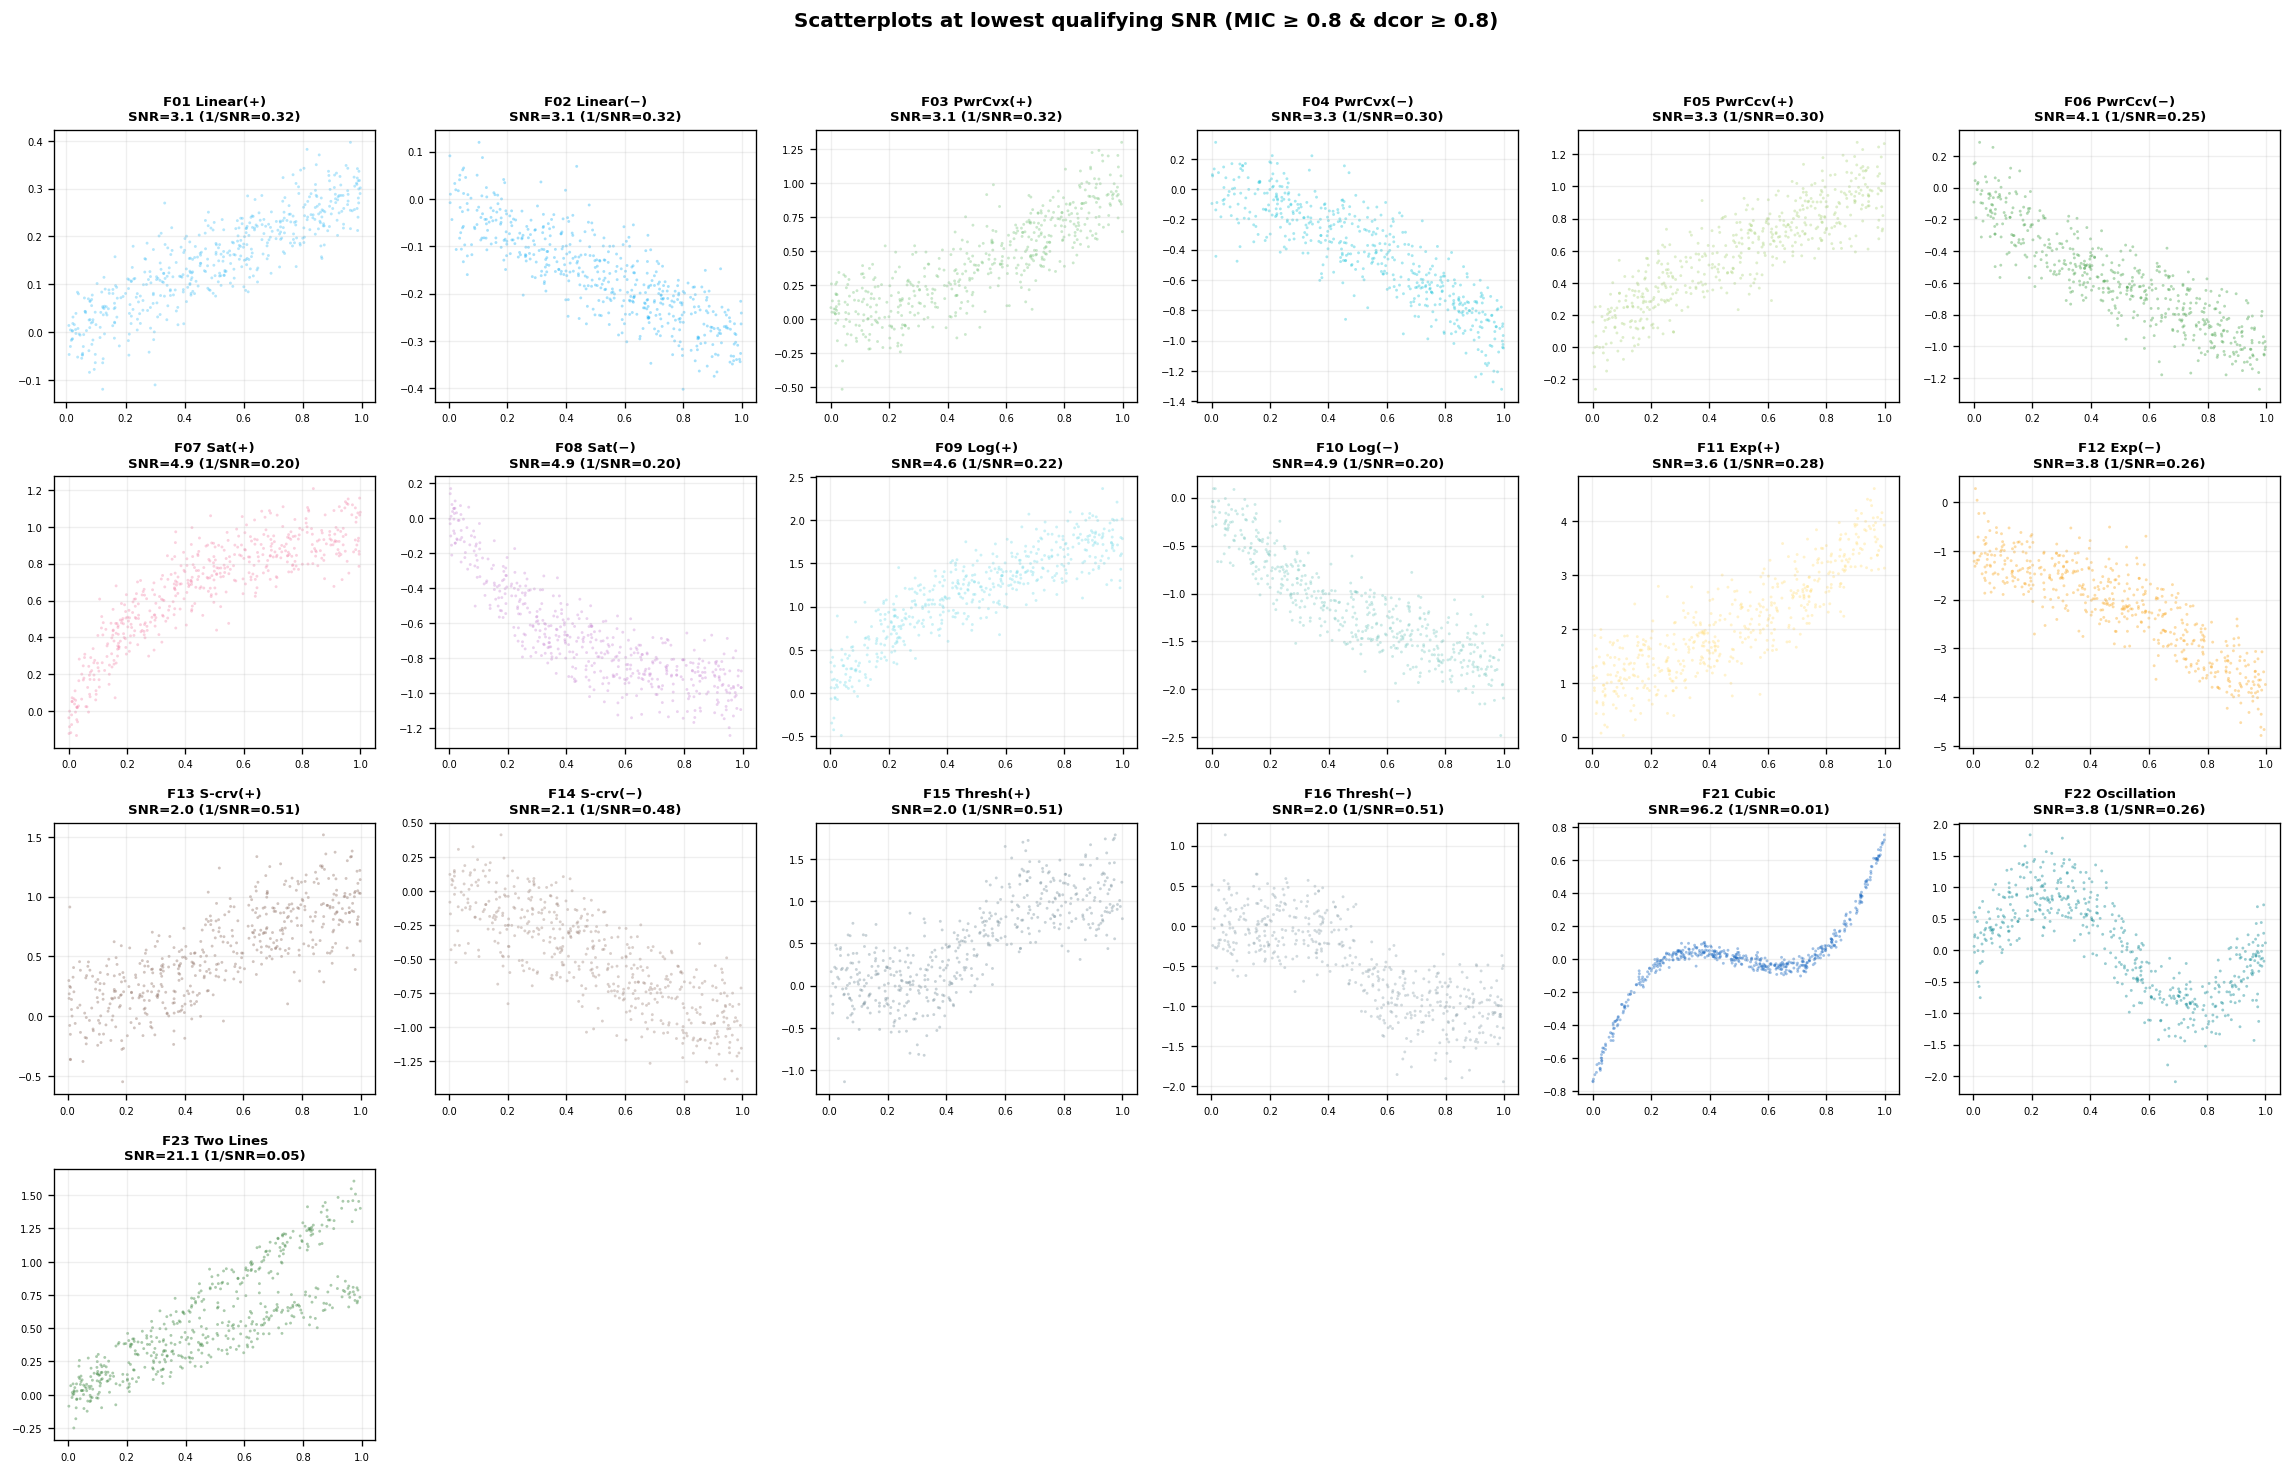

In [1020]:
# ── Scatterplots: each family at its lowest qualifying SNR ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

ncols = 6
nrows = math.ceil(len(qual_fids) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
axes = axes.flatten()

for i, fid in enumerate(qual_fids):
    ax = axes[i]
    # Find lowest finite SNR that passes filter
    fsub = filtered_cases[filtered_cases['family_id'] == fid]
    finite_snrs = fsub['snr_val'][np.isfinite(fsub['snr_val'])].drop_duplicates().sort_values()
    if len(finite_snrs) == 0:
        ax.set_visible(False)
        continue
    low_snr = finite_snrs.iloc[0]
    # Pick first replicate at this (family, snr)
    match = cases_df[(cases_df['family_id'] == fid) & (cases_df['snr'] == low_snr)]
    if len(match) == 0:
        ax.set_visible(False)
        continue
    idx = match.index[0]
    x, y = X_all[idx], Y_all[idx]
    ax.scatter(x, y, s=3, alpha=0.4, color=FAMILY_PALETTE[fid], edgecolors='none')
    ax.set_title(f'{fid} {SHORT[fid]}\nSNR={low_snr:.1f} (1/SNR={1/low_snr:.2f})',
                 fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

for j in range(len(qual_fids), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Scatterplots at lowest qualifying SNR (MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH})',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


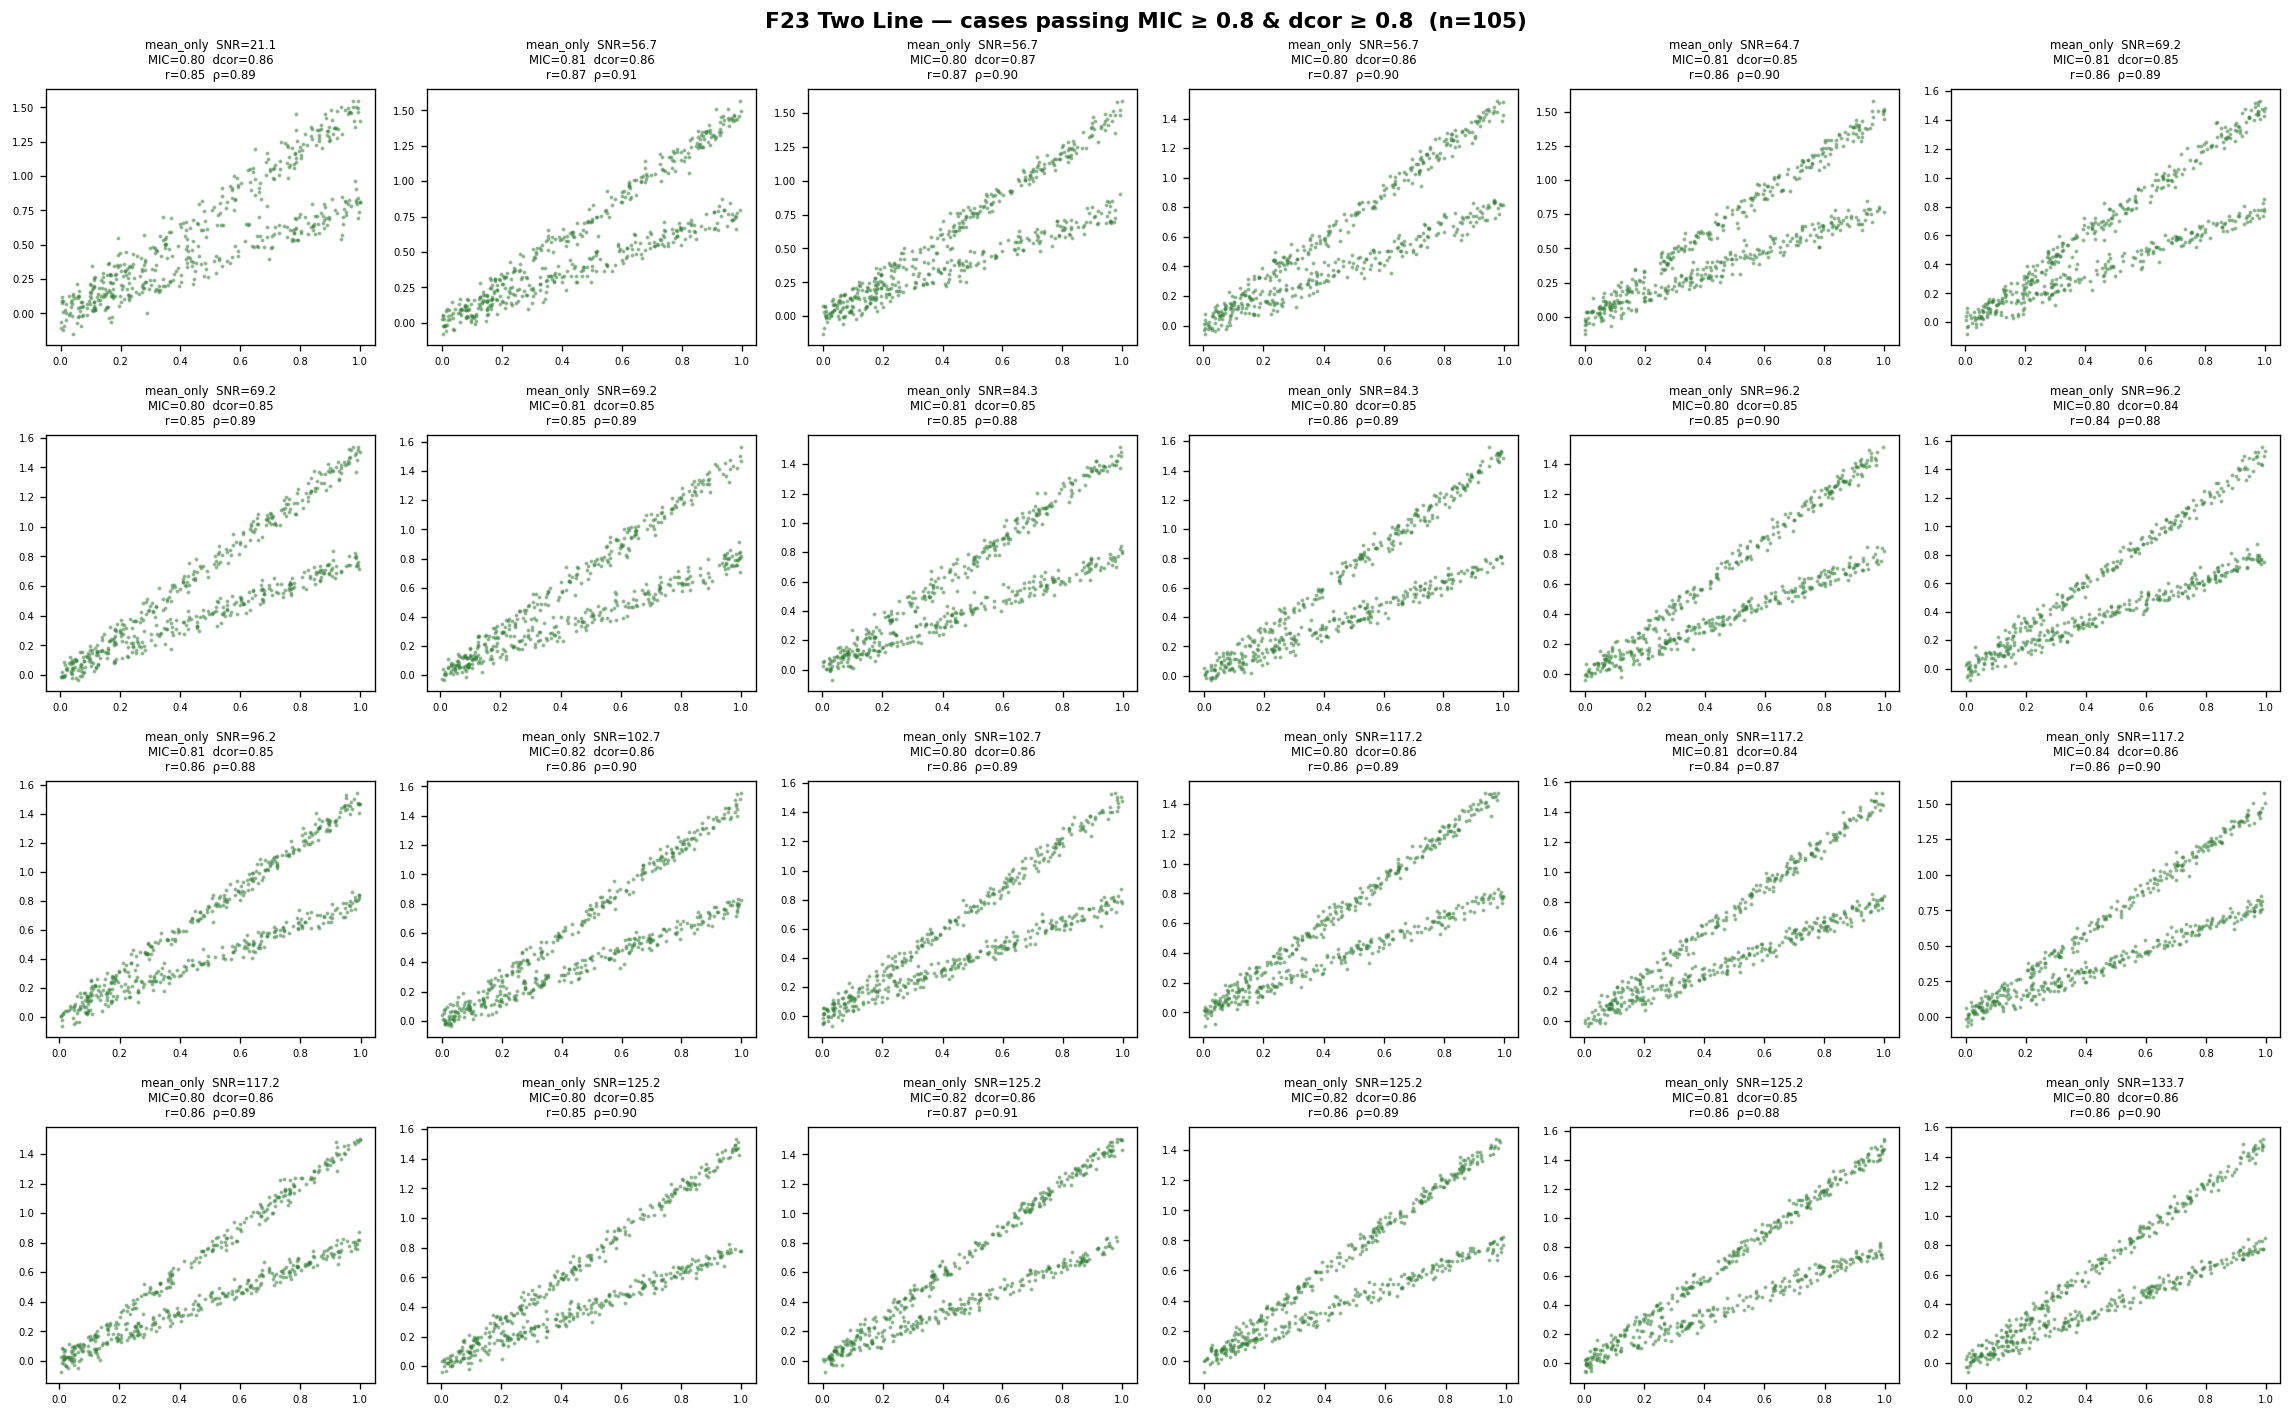

F23 qualifying cases: 105
SNR range: 21.10 – inf
Categories: {'mean_only': 105}


In [1021]:
# ── F23 Two Line: scatterplots of cases passing MIC ≥ 0.8 & dcor ≥ 0.8 ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

f23_pass = filtered_cases[filtered_cases['family_id'] == 'F23'].copy()
f23_pass = f23_pass.sort_values('snr_val', ascending=True)

n_show = min(len(f23_pass), 24)
ncols = 6
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3 * nrows))
axes = np.array(axes).flatten()

for i in range(n_show):
    ax = axes[i]
    row = f23_pass.iloc[i]
    cid = row['case_id']
    match = cases_df[cases_df['case_id'] == cid]
    if len(match) == 0:
        ax.set_visible(False)
        continue
    idx = match.index[0]
    x, y = X_all[idx], Y_all[idx]
    ax.scatter(x, y, s=2, alpha=0.4, color=FAMILY_PALETTE.get('F23', '#888'))
    snr_str = f'SNR={row["snr_val"]:.1f}' if np.isfinite(row['snr_val']) else 'SNR=∞'
    ax.set_title(f'{row["category"]}  {snr_str}\n'
                 f'MIC={row["MIC"]:.2f}  dcor={row["distance_correlation"]:.2f}\n'
                 f'r={row["pearson_r"]:.2f}  ρ={row["spearman_rho"]:.2f}',
                 fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'F23 Two Line — cases passing MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH}  (n={len(f23_pass)})',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print(f'F23 qualifying cases: {len(f23_pass)}')
print(f'SNR range: {f23_pass["snr_val"].min():.2f} – {f23_pass["snr_val"].max()}')
print(f'Categories: {f23_pass["category"].value_counts().to_dict()}')

In [1022]:
# ── Separate filter comparison: MIC only vs dcor only (per case) ──

mic_cases = signal[signal['MIC'] >= MIC_THRESH]
dcor_cases = signal[signal['distance_correlation'] >= DCOR_THRESH]

mic_fids = sorted(mic_cases['family_id'].unique())
dcor_fids = sorted(dcor_cases['family_id'].unique())
both_fids = sorted(set(mic_fids) & set(dcor_fids))
mic_not_dcor = sorted(set(mic_fids) - set(dcor_fids))
dcor_not_mic = sorted(set(dcor_fids) - set(mic_fids))

print(f'MIC ≥ {MIC_THRESH} only:  {len(mic_fids)} families — {mic_fids}')
print(f'dcor ≥ {DCOR_THRESH} only: {len(dcor_fids)} families — {dcor_fids}')
print(f'Both:              {len(both_fids)} families — {both_fids}')
print(f'MIC only (not dcor): {mic_not_dcor}')
print(f'dcor only (not MIC): {dcor_not_mic}')

# Detail table for families that differ
diff_fids = sorted(set(mic_not_dcor) | set(dcor_not_mic))
if diff_fids:
    total_per_fid = signal.groupby('family_id').size()
    print(f'\n{"Family":<28} {"MIC pass":>9} {"dcor pass":>10} {"max MIC":>8} {"max dcor":>9}')
    print('─' * 68)
    for fid in diff_fids:
        sub = signal[signal['family_id'] == fid]
        n_mic = (sub['MIC'] >= MIC_THRESH).sum()
        n_dcor = (sub['distance_correlation'] >= DCOR_THRESH).sum()
        print(f'{fid + " " + SHORT.get(fid, ""):<28} '
              f'{n_mic:>8} {n_dcor:>10} '
              f'{sub["MIC"].max():>8.3f} {sub["distance_correlation"].max():>9.3f}')


MIC ≥ 0.8 only:  25 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F25', 'F26']
dcor ≥ 0.8 only: 19 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
Both:              19 families — ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F21', 'F22', 'F23']
MIC only (not dcor): ['F17', 'F18', 'F19', 'F20', 'F25', 'F26']
dcor only (not MIC): []

Family                        MIC pass  dcor pass  max MIC  max dcor
────────────────────────────────────────────────────────────────────
F17 Peak(∩)                      2017          0    1.000     0.525
F18 Valley(∪)                    2019          0    1.000     0.526
F19 Spike                         869          0    1.000     0.529
F20 Inv Spike                 

## Step 2 — Metric vs 1/SNR (only qualifying families & SNR levels)

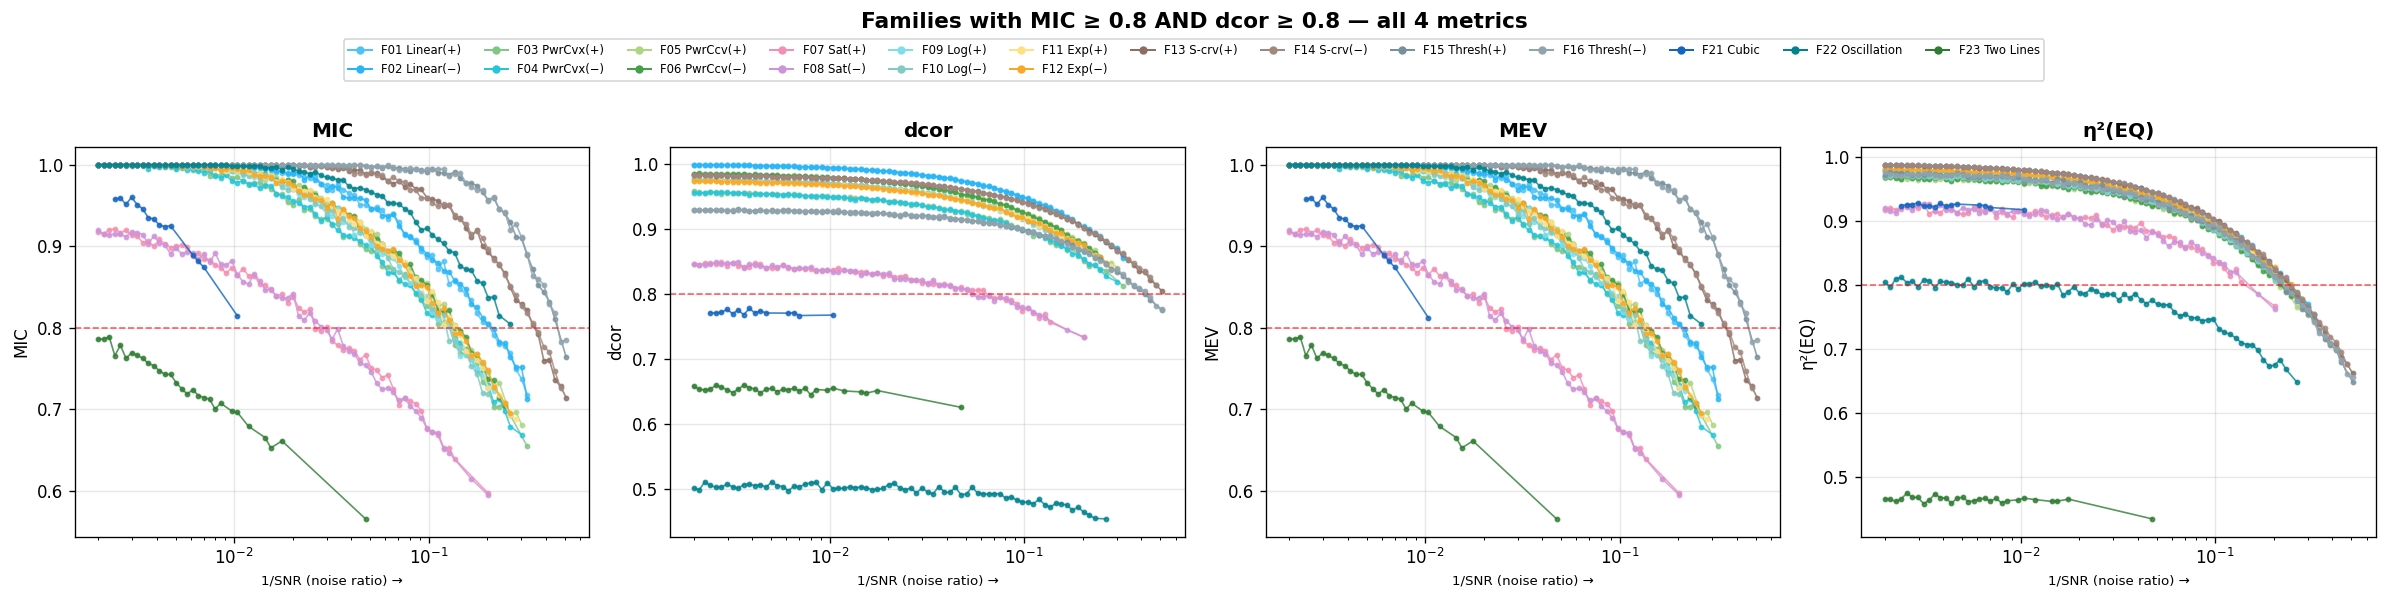

In [1023]:
# ── 1×4 combined: only families/SNR pairs where MIC ≥ 0.8 & dcor ≥ 0.8 ──

fig, axes = plt.subplots(1, len(COMB_METRICS), figsize=(5 * len(COMB_METRICS), 4.5))

for ax, (col, label) in zip(axes, COMB_METRICS):
    for fid in qual_fids:
        # Only plot (family, snr) pairs that passed the dual filter
        pass_snrs = set(filtered_cases[filtered_cases['family_id'] == fid]['snr_val'])
        sub = signal[signal['family_id'] == fid]
        agg_full = sub.groupby('snr_val')[col].mean().reset_index()
        agg_full = agg_full[agg_full['snr_val'].isin(pass_snrs)].copy()
        agg_full = agg_full[np.isfinite(agg_full['snr_val']) & (agg_full['snr_val'] > 0)].copy()
        if len(agg_full) == 0:
            continue
        agg_full['noise_ratio'] = 1.0 / agg_full['snr_val']
        agg_full = agg_full.sort_values('noise_ratio')
        ax.plot(agg_full['noise_ratio'], agg_full[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.axhline(MIC_THRESH, color='red', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel(label)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                  markersize=4, linewidth=1.2,
                  label=f'{f} {SHORT.get(f, "")}') for f in qual_fids]
fig.legend(handles=handles, loc='upper center', ncol=min(13, len(qual_fids)),
           fontsize=7, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f'Families with MIC ≥ {MIC_THRESH} AND dcor ≥ {DCOR_THRESH} — all 4 metrics',
             fontsize=13, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()

## Step 3 — Scatterplots at the MIC & dcor ≈ 0.8 boundary


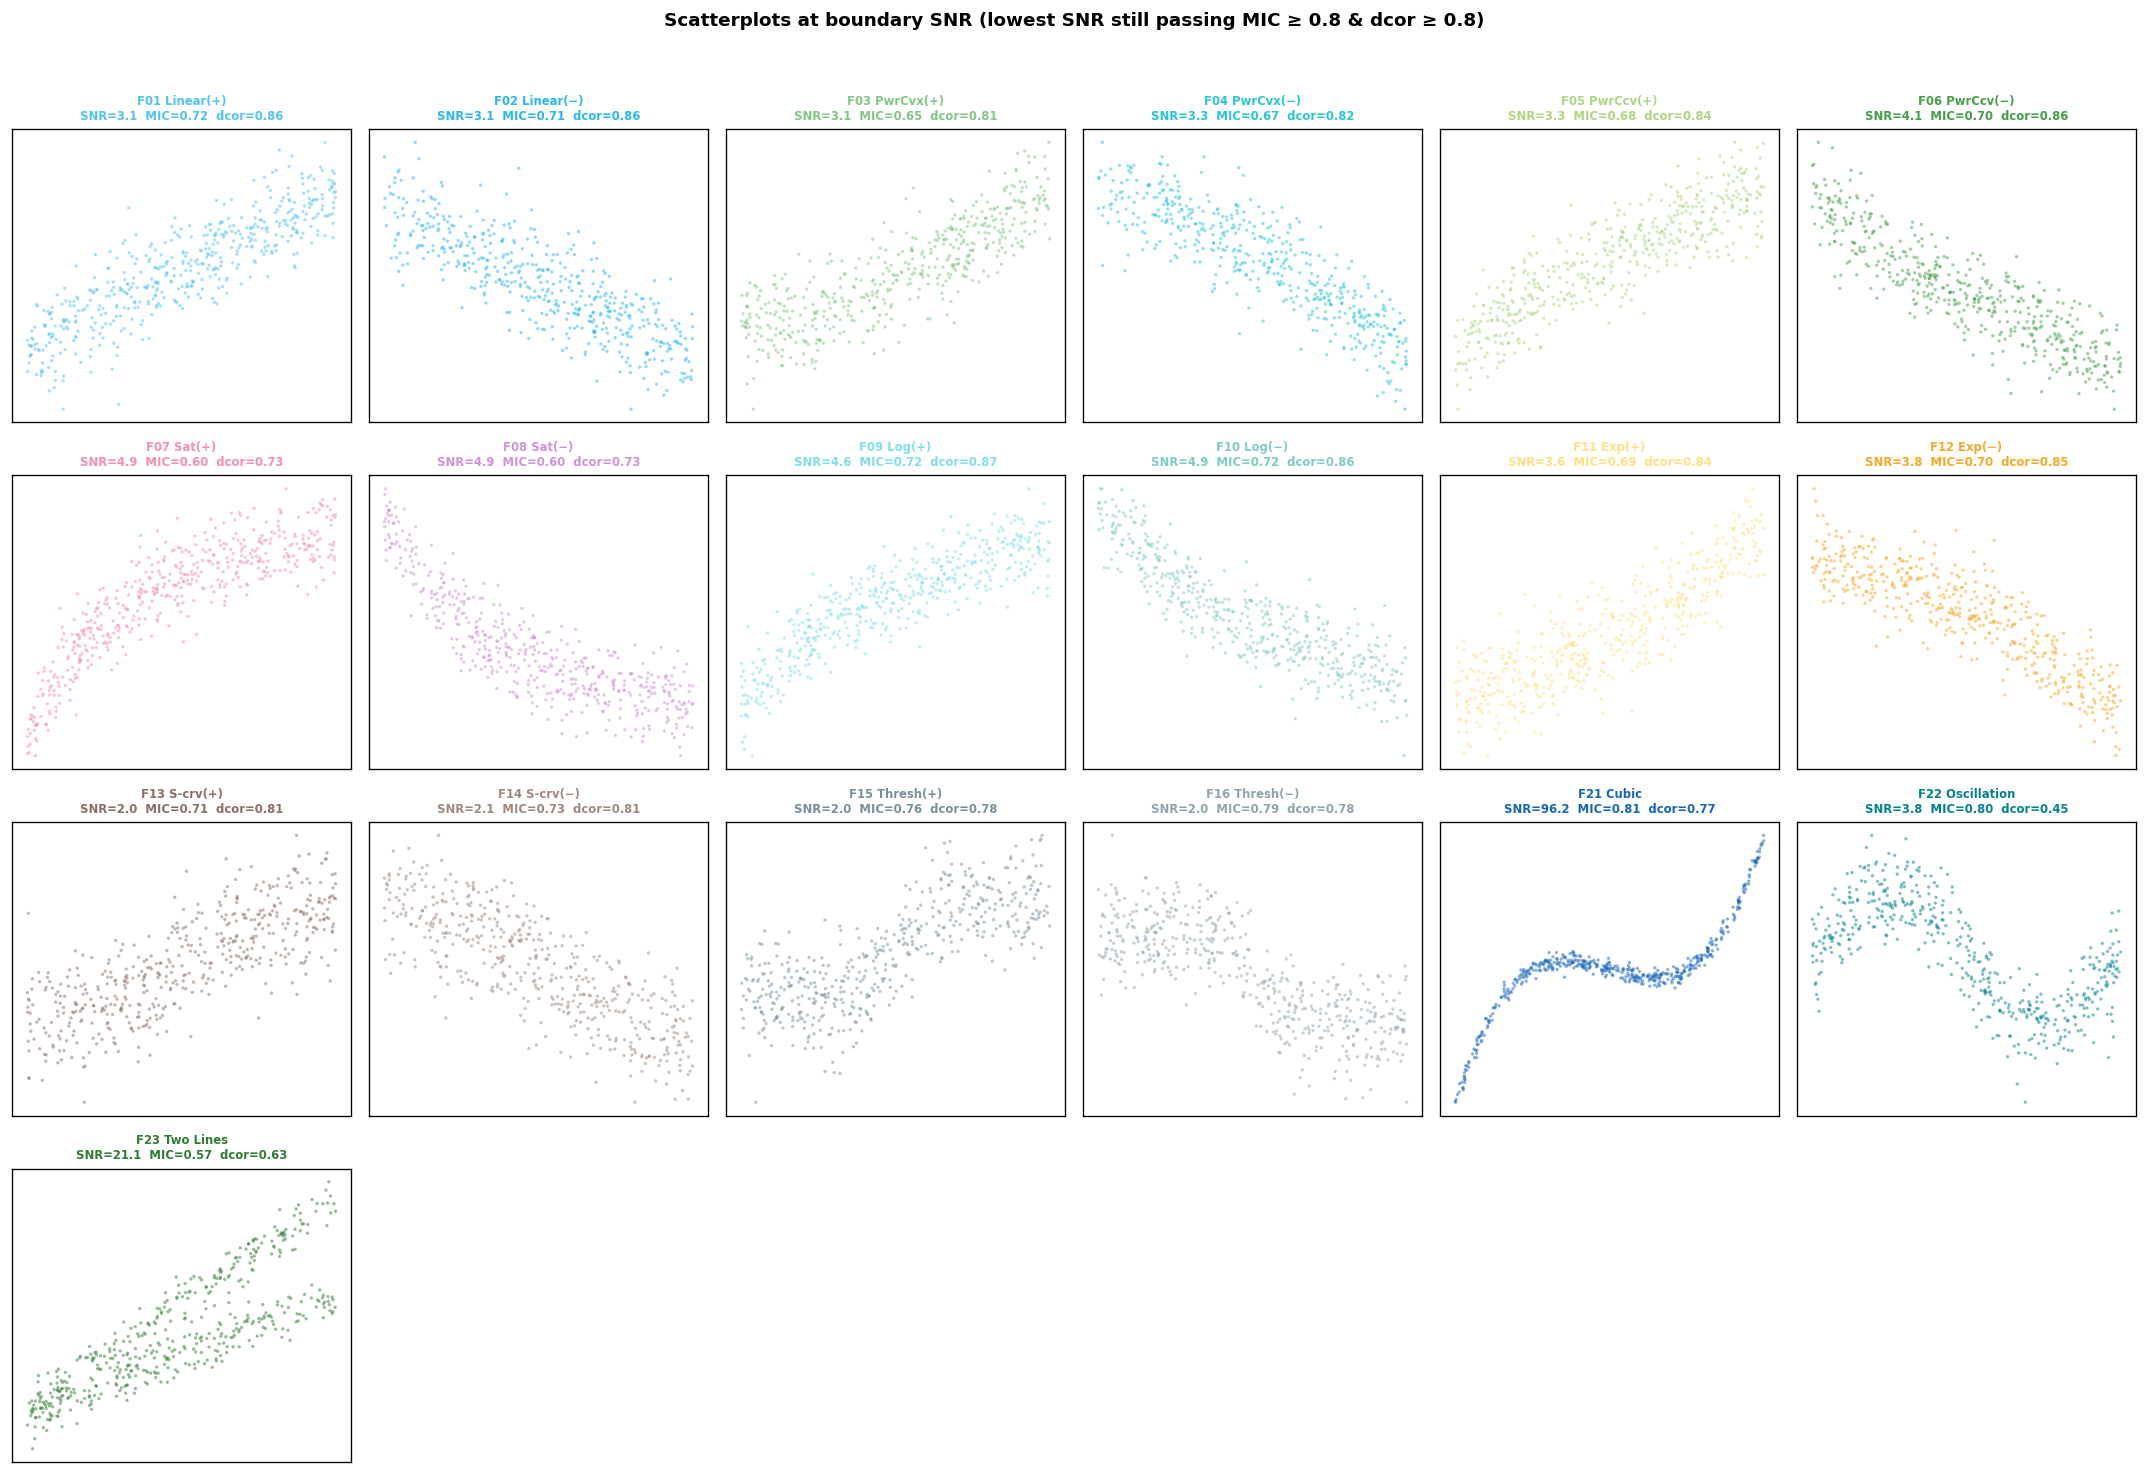

In [1024]:
# ── Scatterplots: each qualifying family at the SNR where it drops below the dual threshold ──

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_df['snr_f'] = cases_df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

n = len(qual_fids)
ncols_g = min(6, n)
nrows_g = math.ceil(n / ncols_g)
fig, axes = plt.subplots(nrows_g, ncols_g, figsize=(3 * ncols_g, 3 * nrows_g))
if nrows_g * ncols_g == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes).reshape(nrows_g, ncols_g)

for idx, fid in enumerate(qual_fids):
    r, c = divmod(idx, ncols_g)
    ax = axes[r, c]

    # Find the lowest SNR that still passes the dual filter
    pass_snrs = filtered_cases[filtered_cases['family_id'] == fid]['snr_val'].drop_duplicates()
    finite_pass = pass_snrs[np.isfinite(pass_snrs)]
    if len(finite_pass) == 0:
        ax.set_visible(False)
        continue
    boundary_snr = finite_pass.min()

    pick = cases_df[(cases_df['family_id'] == fid) &
                    (np.isclose(cases_df['snr_f'], boundary_snr, rtol=1e-6)) &
                    (cases_df['replicate'] == 0)]
    if len(pick) == 0:
        pick = cases_df[(cases_df['family_id'] == fid) &
                        (np.isclose(cases_df['snr_f'], boundary_snr, rtol=1e-3))].head(1)
    if len(pick) == 0:
        ax.set_visible(False)
        continue
    ci = pick.index[0]

    # Get actual metric values at this SNR
    sub = signal[(signal['family_id'] == fid) & (np.isclose(signal['snr_val'], boundary_snr, rtol=1e-6))]
    mic_val = sub['MIC'].mean()
    dcor_val = sub['distance_correlation'].mean()

    ax.scatter(X_all[ci], Y_all[ci], s=4, alpha=0.5,
               color=FAMILY_PALETTE[fid], edgecolors='none')
    ax.set_title(f'{fid} {SHORT[fid]}\nSNR={boundary_snr:.1f}  MIC={mic_val:.2f}  dcor={dcor_val:.2f}',
                 fontsize=7, fontweight='bold', color=FAMILY_PALETTE[fid])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)

for idx in range(n, nrows_g * ncols_g):
    r, c = divmod(idx, ncols_g)
    axes[r, c].set_visible(False)

fig.suptitle(f'Scatterplots at boundary SNR (lowest SNR still passing MIC ≥ {MIC_THRESH} & dcor ≥ {DCOR_THRESH})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Complexity Classification: Pearson/Spearman + MAS/MIC-r²

In [1038]:
# ── Classify qualifying families by relationship type ──

R_THRESH = 0.7
NL_THRESH = 0.3
MR_THRESH = 0.3

# ── Bin-level turning-point guard ──
BIN_N = 10
BIN_SLOPE_EPS = 0.10        # slope in z(y) per normalized x unit
BIN_MIN_RUN = 1             # one clear bin-to-bin slope per direction; prominence controls noise
BIN_MIN_PROMINENCE = 0.15   # peak/valley height in standardized y units
BIN_ROLLING_WINDOW = 3      # rolling median over binned y

if 'X_all' not in globals() or 'Y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    X_all, Y_all = pts['x'], pts['y']

if '_case_idx_by_id' not in globals():
    _case_idx_by_id = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

if '_bin_turn_cache' not in globals():
    _bin_turn_cache = {}


def _run_intervals(sign):
    runs = []
    i = 0
    while i < len(sign):
        if sign[i] == 0:
            i += 1
            continue
        s = int(sign[i])
        j = i
        while j + 1 < len(sign) and sign[j + 1] == s:
            j += 1
        runs.append((s, i, j, j - i + 1))
        i = j + 1
    return runs


def _turn_prominence(yb, first_run, second_run):
    s1, i1, j1, _ = first_run
    s2, i2, j2, _ = second_run
    lo, hi = i1, j2 + 1
    seg = yb[lo:hi + 1]
    if len(seg) < 3:
        return 0.0

    if s1 == 1 and s2 == -1:
        k = int(np.nanargmax(seg)) + lo
        left = yb[lo:k + 1]
        right = yb[k:hi + 1]
        return float(min(yb[k] - np.nanmin(left), yb[k] - np.nanmin(right)))
    if s1 == -1 and s2 == 1:
        k = int(np.nanargmin(seg)) + lo
        left = yb[lo:k + 1]
        right = yb[k:hi + 1]
        return float(min(np.nanmax(left) - yb[k], np.nanmax(right) - yb[k]))
    return 0.0


def _bin_turn_stats(case_id):
    case_id = int(case_id)
    if case_id in _bin_turn_cache:
        return _bin_turn_cache[case_id]

    idx = _case_idx_by_id.get(case_id)
    if idx is None:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': np.nan,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    x = np.asarray(X_all[idx], dtype=float)
    y = np.asarray(Y_all[idx], dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < BIN_N * 3 or np.nanmax(x) <= np.nanmin(x) or np.nanstd(y) <= 0:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': 0.0,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    order = np.argsort(x)
    xn = (x[order] - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-12)
    yz = (y[order] - np.nanmean(y)) / (np.nanstd(y) + 1e-12)

    chunks = np.array_split(np.arange(len(xn)), BIN_N)
    xb = np.array([np.nanmedian(xn[ch]) for ch in chunks if len(ch) > 0], dtype=float)
    yb = np.array([np.nanmedian(yz[ch]) for ch in chunks if len(ch) > 0], dtype=float)
    keep = np.isfinite(xb) & np.isfinite(yb)
    xb, yb = xb[keep], yb[keep]
    if len(xb) < 5:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': 0.0,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    if BIN_ROLLING_WINDOW and BIN_ROLLING_WINDOW > 1:
        yb_s = pd.Series(yb).rolling(BIN_ROLLING_WINDOW, center=True, min_periods=1).median().to_numpy()
    else:
        yb_s = yb.copy()

    dx = np.diff(xb)
    dy = np.diff(yb_s)
    valid = np.abs(dx) > 1e-12
    slopes = np.full_like(dy, np.nan, dtype=float)
    slopes[valid] = dy[valid] / dx[valid]

    sign = np.zeros(len(slopes), dtype=int)
    sign[slopes > BIN_SLOPE_EPS] = 1
    sign[slopes < -BIN_SLOPE_EPS] = -1

    runs = _run_intervals(sign)
    pos_runs = sum(1 for r in runs if r[0] == 1 and r[3] >= BIN_MIN_RUN)
    neg_runs = sum(1 for r in runs if r[0] == -1 and r[3] >= BIN_MIN_RUN)

    sign_changes = 0
    max_prom = 0.0
    for a, b in zip(runs[:-1], runs[1:]):
        if a[0] == b[0]:
            continue
        sign_changes += 1
        if a[3] < BIN_MIN_RUN or b[3] < BIN_MIN_RUN:
            continue
        max_prom = max(max_prom, _turn_prominence(yb_s, a, b))

    has_turn = (pos_runs > 0 and neg_runs > 0 and max_prom >= BIN_MIN_PROMINENCE)

    out = {
        'bin_has_turn': bool(has_turn),
        'bin_sign_changes': int(sign_changes),
        'bin_max_prominence': float(max_prom),
        'bin_pos_runs': int(pos_runs),
        'bin_neg_runs': int(neg_runs),
    }
    _bin_turn_cache[case_id] = out
    return out


def _add_bin_turn_columns(df, label='cases'):
    rows = []
    case_ids = df['case_id'].to_numpy()
    for k, cid in enumerate(case_ids, 1):
        rows.append(_bin_turn_stats(cid))
        if k % 5000 == 0:
            print(f'  Bin TP check: {k:,}/{len(case_ids):,} {label}')
    stats = pd.DataFrame(rows, index=df.index)
    return df.join(stats)


# Per case: check each criterion independently
fc = filtered_cases.copy()
fc['pass_pearson'] = (fc['pearson_r'].abs() >= R_THRESH).astype(int)
fc['pass_spearman'] = (fc['spearman_rho'].abs() >= R_THRESH).astype(int)
fc['pass_mas'] = (fc['MAS'] < NL_THRESH).astype(int)
fc['pass_mic_r2'] = (fc['MIC_minus_r2'] < MR_THRESH).astype(int)

# Bin TP guard: equal-count bins -> median y -> rolling median -> robust slope sign change + prominence.
fc = _add_bin_turn_columns(fc, label='filtered cases')
fc['pass_bin_no_turn'] = (~fc['bin_has_turn']).astype(int)

fc['pass_all'] = (
    fc['pass_pearson'] &
    fc['pass_spearman'] &
    fc['pass_mas'] &
    fc['pass_mic_r2'] &
    fc['pass_bin_no_turn']
).astype(int)

n_pass_all_cases = int(fc['pass_all'].sum())
n_bin_turn = int(fc['bin_has_turn'].sum())
n_bin_turn_base = int((
    (fc['pass_pearson'] == 1) &
    (fc['pass_spearman'] == 1) &
    (fc['pass_mas'] == 1) &
    (fc['pass_mic_r2'] == 1) &
    (fc['bin_has_turn'])
).sum())

print(f'═══ Step 4: Simple/Complex Classification ═══')
print(f'Input: {len(fc):,} cases from Step 1  (out of {len(signal):,} total)')
print(f'Rule:  |r| ≥ {R_THRESH}  AND  |ρ| ≥ {R_THRESH}  AND  MAS < {NL_THRESH}  AND  MIC-r² < {MR_THRESH}')
print(f'       AND no robust bin-level turning point')
print(f'Bin TP guard: bins={BIN_N}, slope_eps={BIN_SLOPE_EPS}, min_run={BIN_MIN_RUN}, prominence≥{BIN_MIN_PROMINENCE}, rolling={BIN_ROLLING_WINDOW}')
print(f'  Cases with robust bin TP: {n_bin_turn:,} / {len(fc):,} ({n_bin_turn/len(fc):.1%})')
print(f'  Base pass-all cases moved out by bin TP: {n_bin_turn_base:,}')
print(f'  Cases passing ALL 5: {n_pass_all_cases:,} / {len(fc):,} ({n_pass_all_cases/len(fc):.1%} of filtered, {n_pass_all_cases/len(signal):.1%} of total)')
print()

# Build rows with classification
simple, nonlinear_mono, complex_nl = [], [], []
cat_cases = {'simple': 0, 'mono_nl': 0, 'complex': 0}
row_data = []
for fid in qual_fids:
    sub = fc[fc['family_id'] == fid]
    n = len(sub)
    p_r = sub['pass_pearson'].mean()
    p_s = sub['pass_spearman'].mean()
    p_m = sub['pass_mas'].mean()
    p_mr = sub['pass_mic_r2'].mean()
    p_bt = sub['pass_bin_no_turn'].mean()
    p_all = sub['pass_all'].mean()
    n_turn = int(sub['bin_has_turn'].sum())

    if p_all >= 0.5:
        category = '✓ Simple'
        simple.append(fid)
        cat_cases['simple'] += n
    elif p_r >= 0.5 and p_s >= 0.5 and p_bt >= 0.5:
        category = '△ Mono+NL'
        nonlinear_mono.append(fid)
        cat_cases['mono_nl'] += n
    else:
        category = '✗ Complex'
        complex_nl.append(fid)
        cat_cases['complex'] += n

    row_data.append(f'{fid} {SHORT[fid]:<10} {p_r:>4.0%} {p_s:>4.0%} {p_m:>4.0%} {p_mr:>4.0%} {p_bt:>5.0%} {n_turn:>4} {n:>5} {category}')

# Print in two columns
mid = (len(row_data) + 1) // 2
col_w = 65
hdr = f'{"Family":<16} {"r":>4} {"ρ":>4} {"MAS":>4} {"MR²":>4} {"BinTP":>5} {"Turn":>4} {"N":>5} {"Cat"}'
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{"─"*col_w}  {"─"*col_w}')
for i in range(mid):
    left = row_data[i]
    right = row_data[i + mid] if i + mid < len(row_data) else ''
    print(f'{left:<{col_w}}  {right}')

print(f'\nSummary ({len(fc):,} Step-1-filtered / {len(signal):,} total):')
print(f'  ✓ Simple monotonic:      {len(simple):>2} fam, {cat_cases["simple"]:>6,} cases ({cat_cases["simple"]/len(fc):.1%})')
print(f'  △ Monotonic + nonlinear: {len(nonlinear_mono):>2} fam, {cat_cases["mono_nl"]:>6,} cases ({cat_cases["mono_nl"]/len(fc):.1%})')
print(f'  ✗ Non-mono / complex:    {len(complex_nl):>2} fam, {cat_cases["complex"]:>6,} cases ({cat_cases["complex"]/len(fc):.1%})')

# ── Plot: per-case pass rates vs 1/SNR ──
CLS_METRICS = [
    ('pass_pearson',     f'|Pearson| ≥ {R_THRESH}'),
    ('pass_spearman',    f'|Spearman| ≥ {R_THRESH}'),
    ('pass_mas',         f'MAS < {NL_THRESH}'),
    ('pass_mic_r2',      f'MIC-r² < {MR_THRESH}'),
    ('pass_bin_no_turn', 'No robust bin TP'),
]

fig, axes = plt.subplots(1, len(CLS_METRICS), figsize=(5 * len(CLS_METRICS), 4.5))

for ax, (col, label) in zip(axes, CLS_METRICS):
    for fid in qual_fids:
        sub = fc[fc['family_id'] == fid]
        agg_m = sub.groupby('snr_val')[col].mean().reset_index()
        agg_m = agg_m[np.isfinite(agg_m['snr_val']) & (agg_m['snr_val'] > 0)].copy()
        agg_m['noise_ratio'] = 1.0 / agg_m['snr_val']
        agg_m = agg_m.sort_values('noise_ratio')
        ax.plot(agg_m['noise_ratio'], agg_m[col], '-o',
                color=FAMILY_PALETTE[fid],
                markersize=2.5, linewidth=1.0, alpha=0.8,
                label=f'{fid} {SHORT.get(fid, "")}')
    ax.axhline(0.8, color='green', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('1/SNR (noise ratio) →', fontsize=8)
    ax.set_ylabel('% cases passing')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=FAMILY_PALETTE[f], marker='o',
                  markersize=4, linewidth=1.2,
                  label=f'{f} {SHORT.get(f, "")}') for f in qual_fids]
fig.legend(handles=handles, loc='upper center', ncol=min(13, len(qual_fids)),
           fontsize=7, frameon=True, bbox_to_anchor=(0.5, 1.06))
fig.suptitle('% of cases passing each criterion (on filtered cases)',
             fontsize=12, fontweight='bold', y=1.10)
plt.tight_layout()
plt.show()


═══ Combined Classification ═══
Input: 32,570 cases from Step 1  (out of 156,780 total)
Criteria:  |r|,|ρ| ≥ 0.7  |  MAS,MIC-r² < 0.2  |  tp=0 ≥ 80%

Family                         r≥0.7   ρ≥0.7  MAS<0.2  MR²<0.2     ALL   tp=0%   Cases  Category
─────────────────────────────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)                  100%    100%     100%     100%    100%   100%    2151  A: Simple monotonic
F02 Linear(−)                  100%    100%     100%     100%    100%   100%    2162  A: Simple monotonic
F03 PwrCvx(+)                  100%    100%     100%      85%     85%    81%    1890  A: Simple monotonic
F04 PwrCvx(−)                  100%    100%     100%      85%     85%    82%    1899  A: Simple monotonic
F05 PwrCcv(+)                  100%    100%     100%     100%    100%   100%    1974  A: Simple monotonic
F06 PwrCcv(−)                  100%    100%     100%     100%    100%   100%    1981  A: Simple monotonic
F07 Sat(+) 

## Simple Path Classification: Direction → Monotonicity → Linearity → Curvature

In [1026]:
# ── ◇ L2: Simple or Complex? ──
R_THRESH = 0.7
NL_THRESH = 0.3
MR_THRESH = 0.3

# ── Bin-level turning-point guard ──
BIN_N = 10
BIN_SLOPE_EPS = 0.10        # slope in z(y) per normalized x unit
BIN_MIN_RUN = 1             # one clear bin-to-bin slope per direction; prominence controls noise
BIN_MIN_PROMINENCE = 0.15   # peak/valley height in standardized y units
BIN_ROLLING_WINDOW = 3      # rolling median over binned y

if 'X_all' not in globals() or 'Y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    X_all, Y_all = pts['x'], pts['y']

if '_case_idx_by_id' not in globals():
    _case_idx_by_id = pd.Series(np.arange(len(cases)), index=cases['case_id']).to_dict()

if '_bin_turn_cache' not in globals():
    _bin_turn_cache = {}


def _run_intervals(sign):
    runs = []
    i = 0
    while i < len(sign):
        if sign[i] == 0:
            i += 1
            continue
        s = int(sign[i])
        j = i
        while j + 1 < len(sign) and sign[j + 1] == s:
            j += 1
        runs.append((s, i, j, j - i + 1))
        i = j + 1
    return runs


def _turn_prominence(yb, first_run, second_run):
    s1, i1, j1, _ = first_run
    s2, i2, j2, _ = second_run
    lo, hi = i1, j2 + 1
    seg = yb[lo:hi + 1]
    if len(seg) < 3:
        return 0.0

    if s1 == 1 and s2 == -1:
        k = int(np.nanargmax(seg)) + lo
        left = yb[lo:k + 1]
        right = yb[k:hi + 1]
        return float(min(yb[k] - np.nanmin(left), yb[k] - np.nanmin(right)))
    if s1 == -1 and s2 == 1:
        k = int(np.nanargmin(seg)) + lo
        left = yb[lo:k + 1]
        right = yb[k:hi + 1]
        return float(min(np.nanmax(left) - yb[k], np.nanmax(right) - yb[k]))
    return 0.0


def _bin_turn_stats(case_id):
    case_id = int(case_id)
    if case_id in _bin_turn_cache:
        return _bin_turn_cache[case_id]

    idx = _case_idx_by_id.get(case_id)
    if idx is None:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': np.nan,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    x = np.asarray(X_all[idx], dtype=float)
    y = np.asarray(Y_all[idx], dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < BIN_N * 3 or np.nanmax(x) <= np.nanmin(x) or np.nanstd(y) <= 0:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': 0.0,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    order = np.argsort(x)
    xn = (x[order] - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-12)
    yz = (y[order] - np.nanmean(y)) / (np.nanstd(y) + 1e-12)

    chunks = np.array_split(np.arange(len(xn)), BIN_N)
    xb = np.array([np.nanmedian(xn[ch]) for ch in chunks if len(ch) > 0], dtype=float)
    yb = np.array([np.nanmedian(yz[ch]) for ch in chunks if len(ch) > 0], dtype=float)
    keep = np.isfinite(xb) & np.isfinite(yb)
    xb, yb = xb[keep], yb[keep]
    if len(xb) < 5:
        out = {
            'bin_has_turn': False,
            'bin_sign_changes': 0,
            'bin_max_prominence': 0.0,
            'bin_pos_runs': 0,
            'bin_neg_runs': 0,
        }
        _bin_turn_cache[case_id] = out
        return out

    if BIN_ROLLING_WINDOW and BIN_ROLLING_WINDOW > 1:
        yb_s = pd.Series(yb).rolling(BIN_ROLLING_WINDOW, center=True, min_periods=1).median().to_numpy()
    else:
        yb_s = yb.copy()

    dx = np.diff(xb)
    dy = np.diff(yb_s)
    valid = np.abs(dx) > 1e-12
    slopes = np.full_like(dy, np.nan, dtype=float)
    slopes[valid] = dy[valid] / dx[valid]

    sign = np.zeros(len(slopes), dtype=int)
    sign[slopes > BIN_SLOPE_EPS] = 1
    sign[slopes < -BIN_SLOPE_EPS] = -1

    runs = _run_intervals(sign)
    pos_runs = sum(1 for r in runs if r[0] == 1 and r[3] >= BIN_MIN_RUN)
    neg_runs = sum(1 for r in runs if r[0] == -1 and r[3] >= BIN_MIN_RUN)

    sign_changes = 0
    max_prom = 0.0
    for a, b in zip(runs[:-1], runs[1:]):
        if a[0] == b[0]:
            continue
        sign_changes += 1
        if a[3] < BIN_MIN_RUN or b[3] < BIN_MIN_RUN:
            continue
        max_prom = max(max_prom, _turn_prominence(yb_s, a, b))

    has_turn = (pos_runs > 0 and neg_runs > 0 and max_prom >= BIN_MIN_PROMINENCE)

    out = {
        'bin_has_turn': bool(has_turn),
        'bin_sign_changes': int(sign_changes),
        'bin_max_prominence': float(max_prom),
        'bin_pos_runs': int(pos_runs),
        'bin_neg_runs': int(neg_runs),
    }
    _bin_turn_cache[case_id] = out
    return out


def _add_bin_turn_columns(df, label='cases'):
    rows = []
    case_ids = df['case_id'].to_numpy()
    for k, cid in enumerate(case_ids, 1):
        rows.append(_bin_turn_stats(cid))
        if k % 5000 == 0:
            print(f'  Bin TP check: {k:,}/{len(case_ids):,} {label}')
    stats = pd.DataFrame(rows, index=df.index)
    return df.join(stats)


sc = filtered_cases.copy()

# Base Simple rule: strong monotone + low nonlinearity/asymmetry metrics.
sc['is_simple_metric'] = (
    (sc['MIC_minus_r2'] < MR_THRESH) &
    (sc['MAS'] < NL_THRESH) &
    (sc['spearman_rho'].abs() >= R_THRESH) &
    (sc['pearson_r'].abs() >= R_THRESH)
)

# Bin TP guard: reject robust bin-level turning points.
sc = _add_bin_turn_columns(sc, label='L2 filtered cases')

sc['is_simple'] = sc['is_simple_metric'] & (~sc['bin_has_turn'])
simple_cases = sc[sc['is_simple']].copy()
complex_cases = sc[~sc['is_simple']].copy()

n_metric_simple = int(sc['is_simple_metric'].sum())
n_bin_turn = int((sc['is_simple_metric'] & sc['bin_has_turn']).sum())

print(f'◇ L2: Simple or Complex?')
print(f'  Base rule: MIC-r² < {MR_THRESH}  AND  MAS < {NL_THRESH}  AND  |ρ| ≥ {R_THRESH}  AND  |r| ≥ {R_THRESH}')
print(f'  Bin TP guard: no robust bin-level TP  (bins={BIN_N}, eps={BIN_SLOPE_EPS}, min_run={BIN_MIN_RUN}, prominence≥{BIN_MIN_PROMINENCE})')
print(f'  Base Simple: {n_metric_simple:,} / {len(sc):,} total ({n_metric_simple/len(sc):.1%})')
print(f'  Moved to Complex by robust bin TP: {n_bin_turn:,}')
print(f'  Result: {len(simple_cases):,} Simple / {len(sc):,} total ({len(simple_cases)/len(sc):.1%})')
print()

hdr = f'{"Family":<16} {"Simple":>7} {"Complex":>8} {"Turn":>6} {"Total":>7} {"Simple%":>8}'
sep = '─' * len(hdr)
rows = []
for fid in qual_fids:
    fid_sc = sc[sc['family_id'] == fid]
    n_s = int(fid_sc['is_simple'].sum())
    n_c = len(fid_sc) - n_s
    n_t = n_s + n_c
    n_turn = int((fid_sc['is_simple_metric'] & fid_sc['bin_has_turn']).sum())
    pct = n_s / n_t if n_t > 0 else 0
    rows.append(f'{fid} {SHORT[fid]:<10} {n_s:>7,} {n_c:>8,} {n_turn:>6,} {n_t:>7,} {pct:>7.0%}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')

simple_fids = sorted(simple_cases['family_id'].unique())
print(f'\n→ {len(simple_fids)} families have Simple cases: {simple_fids}')


  LOWESS turn check: 5,000/32,570 L2 filtered cases
  LOWESS turn check: 10,000/32,570 L2 filtered cases
  LOWESS turn check: 15,000/32,570 L2 filtered cases
  LOWESS turn check: 20,000/32,570 L2 filtered cases
  LOWESS turn check: 25,000/32,570 L2 filtered cases
  LOWESS turn check: 30,000/32,570 L2 filtered cases
◇ L2: Simple or Complex?
  Base rule: MIC-r² < 0.3  AND  MAS < 0.3  AND  |ρ| ≥ 0.7  AND  |r| ≥ 0.7
  LOWESS guard: no robust derivative turn  (frac=0.25, eps=0.1, min_span=0.1, min_y_range=0.2)
  Base Simple: 31,475 / 32,570 total (96.6%)
  Moved to Complex by robust LOWESS turn: 3,585
  Result: 27,890 Simple / 32,570 total (85.6%)

Family            Simple  Complex   Turn   Total  Simple%  Family            Simple  Complex   Turn   Total  Simple%
─────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────
F01 Linear(+)    2,151        0      0   2,151    100%     F11 Exp(+)       1,960       14     14   1,974     99%


In [1027]:
# ── ◇ Direction (sign of Pearson r) ──
simple_cases['direction'] = np.where(simple_cases['pearson_r'] > 0, 'Positive', 'Negative')

print(f'◇ Direction: sign of overall slope (Pearson r)')
print(f'  Denominator = Simple cases per family')
print()

hdr = f'{"Family":<16} {"Pos(+)":>7} {"Neg(−)":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_pos = int((sub['direction'] == 'Positive').sum())
    n_neg = int((sub['direction'] == 'Negative').sum())
    maj = '+' if n_pos >= n_neg else '−'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_pos:>7,} {n_neg:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


◇ Direction: sign of overall slope (Pearson r)
  Denominator = Simple cases per family

Family            Pos(+)  Neg(−)   Total  Majority  Family            Pos(+)  Neg(−)   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)    2,151       0   2,151         +    F10 Log(−)           0   1,913   1,913         −
F02 Linear(−)        0   2,162   2,162         −    F11 Exp(+)       1,960       0   1,960         +
F03 PwrCvx(+)    1,732       0   1,732         +    F12 Exp(−)           0   1,961   1,961         −
F04 PwrCvx(−)        0   1,758   1,758         −    F13 S-crv(+)     2,084       0   2,084         +
F05 PwrCcv(+)    1,974       0   1,974         +    F14 S-crv(−)         0   2,066   2,066         −
F06 PwrCcv(−)        0   1,981   1,981         −    F15 Thresh(+)      956       0     956         +
F07 Sat(+)       1,103       0   1,103         +    F16 Thresh(−)        0     970     970         −

In [1028]:
# ── ◇ Monotonicity (|ρ| level) ──
MONO_STRONG = 0.9

simple_cases['monotonicity'] = np.where(
    simple_cases['spearman_rho'].abs() >= MONO_STRONG, 'Strong', 'Med'
)

print(f'◇ Monotonicity: |ρ| ≥ {MONO_STRONG} → Strong, else Med')
print(f'  Denominator = Simple cases per family')
print()

hdr = f'{"Family":<16} {"Strong":>7} {"Med":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_s = int((sub['monotonicity'] == 'Strong').sum())
    n_m = int((sub['monotonicity'] == 'Med').sum())
    maj = 'Strong' if n_s >= n_m else 'Med'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_s:>7,} {n_m:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


◇ Monotonicity: |ρ| ≥ 0.9 → Strong, else Med
  Denominator = Simple cases per family



Family            Strong     Med   Total  Majority  Family            Strong     Med   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)    2,147       4   2,151    Strong    F10 Log(−)       1,913       0   1,913    Strong
F02 Linear(−)    2,156       6   2,162    Strong    F11 Exp(+)       1,935      25   1,960    Strong
F03 PwrCvx(+)    1,619     113   1,732    Strong    F12 Exp(−)       1,940      21   1,961    Strong
F04 PwrCvx(−)    1,630     128   1,758    Strong    F13 S-crv(+)     1,862     222   2,084    Strong
F05 PwrCcv(+)    1,971       3   1,974    Strong    F14 S-crv(−)     1,841     225   2,066    Strong
F06 PwrCcv(−)    1,981       0   1,981    Strong    F15 Thresh(+)      169     787     956       Med
F07 Sat(+)       1,035      68   1,103    Strong    F16 Thresh(−)      170     800     970       Med
F08 Sat(−)       1,048      49   1,097    Strong    F23 Two Lines       29      75     

In [1029]:
# ── ◇ Linearity (|r| level) ──
LIN_STRONG = 0.9

simple_cases['linearity'] = np.where(
    simple_cases['pearson_r'].abs() >= LIN_STRONG, 'Line', 'Med'
)

print(f'◇ Linearity: |r| ≥ {LIN_STRONG} → Line, else Med')
print(f'  Denominator = Simple cases per family')
print()

hdr = f'{"Family":<16} {"Line":>7} {"Med":>7} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    n_line = int((sub['linearity'] == 'Line').sum())
    n_med = int((sub['linearity'] == 'Med').sum())
    maj = 'Line' if n_line >= n_med else 'Med'
    rows.append(f'{fid} {SHORT[fid]:<10} {n_line:>7,} {n_med:>7,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


◇ Linearity: |r| ≥ 0.9 → Line, else Med
  Denominator = Simple cases per family

Family              Line     Med   Total  Majority  Family              Line     Med   Total  Majority
──────────────────────────────────────────────────  ──────────────────────────────────────────────────
F01 Linear(+)    2,135      16   2,151      Line    F10 Log(−)       1,800     113   1,913      Line
F02 Linear(−)    2,148      14   2,162      Line    F11 Exp(+)       1,830     130   1,960      Line
F03 PwrCvx(+)    1,283     449   1,732      Line    F12 Exp(−)       1,833     128   1,961      Line
F04 PwrCvx(−)    1,287     471   1,758      Line    F13 S-crv(+)     1,913     171   2,084      Line
F05 PwrCcv(+)    1,829     145   1,974      Line    F14 S-crv(−)     1,890     176   2,066      Line
F06 PwrCcv(−)    1,828     153   1,981      Line    F15 Thresh(+)      514     442     956      Line
F07 Sat(+)         574     529   1,103      Line    F16 Thresh(−)      522     448     970      Line
F08 Sa

In [1030]:
# ── ◇ Line判定 + Curvature ──
# Line: 多指标 + 可选 slope V_s
# Curvature: 要求 V_s 足够大 + margin，否则 Weak/Uncertain

# ── Line 参数 ──
LINE_MIC_R2   = 0.2   # MIC - r² < this
LINE_MAS      = 0.2   # MAS < this
LINE_RHO_R    = 0.1   # |ρ| - |r| < this
USE_SLOPE_CHECK = True  # ← 开关: True = 额外检查 V_s
LINE_VS_TOL   = 0.25   # V_s < this → slopes consistent enough for Line

# ── Curvature 参数 ──
CURVE_VS_MIN  = 0.35   # V_s ≥ this 才分 curvature，否则 Weak/Uncertain
CURVE_MARGIN  = 0.10   # slope 之间差 > margin 才算明确 ordering

# ── Compute normalized direction-aware slopes for ALL simple cases ──
E_raw = simple_cases['standardized_polyfit_early_slope'].values
M_raw = simple_cases['standardized_polyfit_middle_slope'].values
L_raw = simple_cases['standardized_polyfit_late_slope'].values

scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
scale = np.where(scale == 0, 1, scale)
e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale

dsign = np.where(simple_cases['pearson_r'].values > 0, 1, -1)
e_d = e_n * dsign
m_d = m_n * dsign
l_d = l_n * dsign

simple_cases['e_d'] = e_d
simple_cases['m_d'] = m_d
simple_cases['l_d'] = l_d

# ── V_s for ALL simple cases ──
EPS = 1e-8
slopes = np.column_stack([e_d, m_d, l_d])
slope_mean = np.abs(slopes.mean(axis=1))
slope_sd   = slopes.std(axis=1, ddof=0)
V_s = slope_sd / (slope_mean + EPS)
simple_cases['slope_Vs'] = V_s

# ── Line候选 ──
is_candidate = (
    (simple_cases['monotonicity'] == 'Strong') &
    (simple_cases['linearity'] == 'Line') &
    (simple_cases['MIC_minus_r2'] < LINE_MIC_R2) &
    (simple_cases['MAS'] < LINE_MAS) &
    ((simple_cases['spearman_rho'].abs() - simple_cases['pearson_r'].abs()) < LINE_RHO_R)
)

if USE_SLOPE_CHECK:
    is_line = is_candidate & (V_s < LINE_VS_TOL)
else:
    is_line = is_candidate

# ── Shape classification ──
shape = np.full(len(simple_cases), 'Weak/Uncertain', dtype=object)

# Line
shape[is_line] = 'Line'

# Curvature: 只在 V_s 足够大时才分
not_line = (shape == 'Weak/Uncertain')
curve_ready = not_line & (V_s >= CURVE_VS_MIN)
mg = CURVE_MARGIN

shape[curve_ready & (e_d + mg < m_d) & (m_d + mg < l_d)] = 'Convex'
shape[curve_ready & (e_d > m_d + mg) & (m_d > l_d + mg)] = 'Concave'
shape[curve_ready & (m_d > e_d + mg) & (m_d > l_d + mg)] = 'Inflected'
shape[curve_ready & (m_d < e_d - mg) & (m_d < l_d - mg)] = 'U-shape'

simple_cases['shape'] = shape

line_cases = simple_cases[simple_cases['shape'] == 'Line'].copy()
line_ids = set(line_cases['case_id'])
med_cases = simple_cases[simple_cases['shape'] != 'Line'].copy()
med_fids = sorted(med_cases['family_id'].unique())

# ── Print ──
n_cand = int(is_candidate.sum())
n_line = int(is_line.sum())
n_curve_ready = int(curve_ready.sum())
slope_str = f' + V_s < {LINE_VS_TOL}' if USE_SLOPE_CHECK else ''
print(f'◇ Line判定: |ρ| ≥ {MONO_STRONG} AND |r| ≥ {LIN_STRONG} AND MIC-r² < {LINE_MIC_R2} AND MAS < {LINE_MAS} AND |ρ|-|r| < {LINE_RHO_R}{slope_str}')
print(f'  USE_SLOPE_CHECK = {USE_SLOPE_CHECK}')
print(f'  候选 {n_cand:,} → Line {n_line:,}')
print()
print(f'◇ Curvature: V_s ≥ {CURVE_VS_MIN} AND margin > {CURVE_MARGIN}')
print(f'  Convex:    E+mg < M < L-mg  (加速)')
print(f'  Concave:   E > M+mg > L+mg  (减速)')
print(f'  Inflected: M > E+mg, M > L+mg (S-curve)')
print(f'  U-shape:   M < E-mg, M < L-mg')
print(f'  curve_ready: {n_curve_ready:,}')
print()
print(f'◇ Weak/Uncertain: V_s < {CURVE_VS_MIN} 或 ordering 不明确')
print()

all_shapes = ['Line', 'Convex', 'Concave', 'Inflected', 'U-shape', 'Weak/Uncertain']
for s in all_shapes:
    n = int((simple_cases['shape'] == s).sum())
    print(f'  {s:<16} {n:>6,} ({n/len(simple_cases):>5.1%})')
print(f'  {"Total":<16} {len(simple_cases):>6,}')
print()

hdr = f'{"Family":<16} {"Line":>6} {"Convex":>7} {"Concave":>8} {"Inflect":>8} {"U-shp":>6} {"Weak":>6} {"Total":>7} {"Majority":>9}'
sep = '─' * len(hdr)
rows = []
for fid in simple_fids:
    sub = simple_cases[simple_cases['family_id'] == fid]
    n = len(sub)
    counts = {s: int((sub['shape'] == s).sum()) for s in all_shapes}
    maj = sub['shape'].mode().iloc[0]
    rows.append(f'{fid} {SHORT[fid]:<10} {counts["Line"]:>6,} {counts["Convex"]:>7,} {counts["Concave"]:>8,} {counts["Inflected"]:>8,} {counts["U-shape"]:>6,} {counts["Weak/Uncertain"]:>6,} {n:>7,} {maj:>9}')

mid = (len(rows) + 1) // 2
col_w = len(hdr)
print(f'{hdr:<{col_w}}  {hdr}')
print(f'{sep}  {sep}')
for i in range(mid):
    left = rows[i]
    right = rows[i + mid] if i + mid < len(rows) else ''
    print(f'{left:<{col_w}}  {right}')


◇ Line判定: |ρ| ≥ 0.9 AND |r| ≥ 0.9 AND MIC-r² < 0.2 AND MAS < 0.2 AND |ρ|-|r| < 0.1 + V_s < 0.25
  USE_SLOPE_CHECK = True
  候选 22,956 → Line 5,349

◇ Curvature: V_s ≥ 0.35 AND margin > 0.1
  Convex:    E+mg < M < L-mg  (加速)
  Concave:   E > M+mg > L+mg  (减速)
  Inflected: M > E+mg, M > L+mg (S-curve)
  U-shape:   M < E-mg, M < L-mg
  curve_ready: 20,457

◇ Weak/Uncertain: V_s < 0.35 或 ordering 不明确

  Line              5,349 (19.2%)
  Convex            5,910 (21.2%)
  Concave           7,588 (27.2%)
  Inflected         5,972 (21.4%)
  U-shape               0 ( 0.0%)
  Weak/Uncertain    3,071 (11.0%)
  Total            27,890

Family             Line  Convex  Concave  Inflect  U-shp   Weak   Total  Majority  Family             Line  Convex  Concave  Inflect  U-shp   Weak   Total  Majority
─────────────────────────────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────────────────────────────
F01 Linear(+)   2,135       0        0 

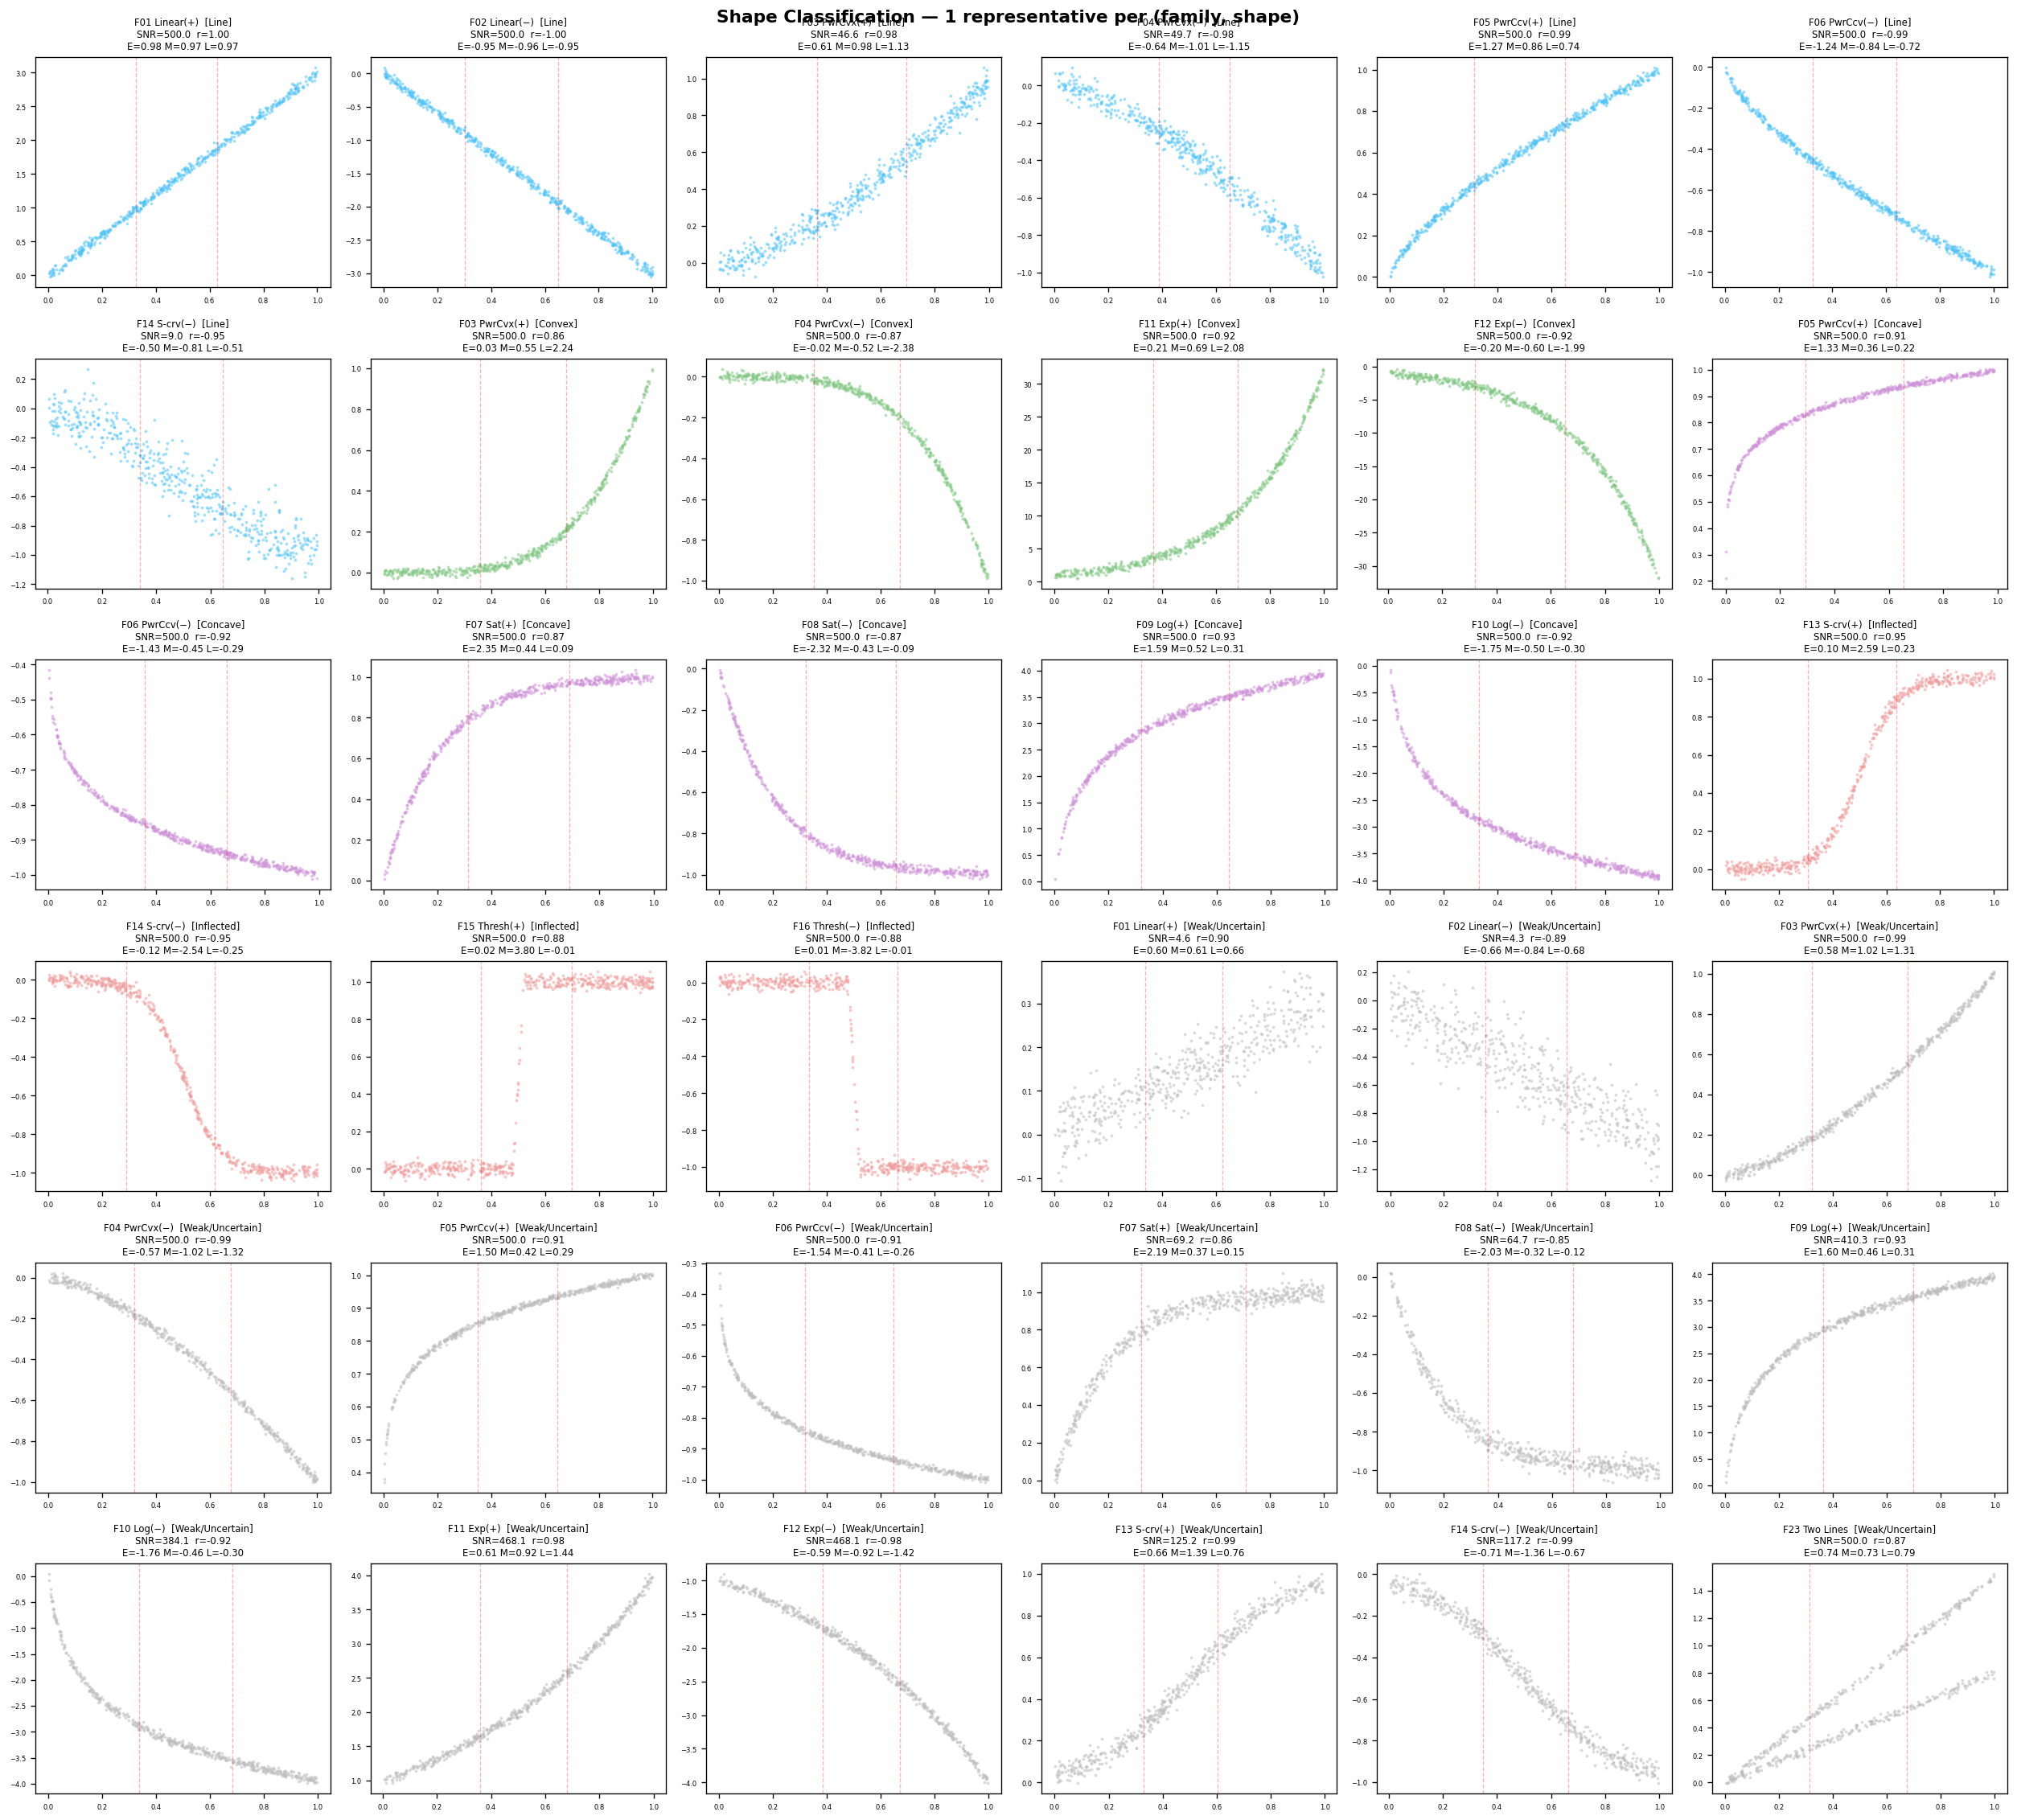

Showing 36 representative cases across 6 shapes


In [1031]:
# ── Scatterplots by shape classification ──
pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)

shape_order = ['Line', 'Convex', 'Concave', 'Inflected', 'U-shape', 'Weak/Uncertain']
shape_colors = {'Line': '#4FC3F7', 'Convex': '#81C784', 'Concave': '#CE93D8',
                'Inflected': '#EF9A9A', 'U-shape': '#FFB74D', 'Weak/Uncertain': '#BDBDBD'}

# For each shape, pick 1 representative case per family (highest SNR)
plot_rows = []
for s in shape_order:
    sub = simple_cases[simple_cases['shape'] == s]
    for fid in sorted(sub['family_id'].unique()):
        fsub = sub[sub['family_id'] == fid]
        # Pick highest finite SNR
        finite = fsub[np.isfinite(fsub['snr_val'])].sort_values('snr_val', ascending=False)
        if len(finite) > 0:
            plot_rows.append(finite.iloc[0])
        elif len(fsub) > 0:
            plot_rows.append(fsub.iloc[0])

n_plots = len(plot_rows)
ncols = 6
nrows = math.ceil(n_plots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.2 * nrows))
axes = np.array(axes).flatten()

for i, row in enumerate(plot_rows):
    ax = axes[i]
    cid = row['case_id']
    match = cases_df[cases_df['case_id'] == cid]
    if len(match) == 0:
        ax.set_visible(False)
        continue
    idx = match.index[0]
    x, y = X_all[idx], Y_all[idx]
    s = row['shape']
    ax.scatter(x, y, s=2, alpha=0.4, color=shape_colors.get(s, '#888'))

    snr_str = f'SNR={row["snr_val"]:.1f}' if np.isfinite(row['snr_val']) else 'SNR=∞'
    e_sl = row['standardized_polyfit_early_slope']
    m_sl = row['standardized_polyfit_middle_slope']
    l_sl = row['standardized_polyfit_late_slope']
    ax.set_title(f'{row["family_id"]} {SHORT.get(row["family_id"],"")}  [{s}]\n'
                 f'{snr_str}  r={row["pearson_r"]:.2f}\n'
                 f'E={e_sl:.2f} M={m_sl:.2f} L={l_sl:.2f}',
                 fontsize=7)
    ax.tick_params(labelsize=5)

    # Draw thirds
    x_sorted = np.sort(x)
    n_pts = len(x_sorted)
    ax.axvline(x_sorted[n_pts//3], color='red', alpha=0.3, linewidth=0.8, linestyle='--')
    ax.axvline(x_sorted[2*n_pts//3], color='red', alpha=0.3, linewidth=0.8, linestyle='--')

for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Shape Classification — 1 representative per (family, shape)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print(f'Showing {n_plots} representative cases across {len(shape_order)} shapes')


═══ Line Diagnostic ═══
Corr-Line but Shape≠Line: 18,422 / 27,890 simple cases
True-line F01/F02 but Shape≠Line: 30

Corr-Line but Shape≠Line by family × shape:


shape,Concave,Convex,Inflected,Weak/Uncertain
family_id,,,,
F03,0,665,0,597
F04,0,676,0,601
F05,849,0,0,465
F06,862,0,0,448
F07,574,0,0,0
F08,577,0,0,0
F09,1677,0,0,131
F10,1668,0,0,132
F11,0,1694,0,136


True-line false negatives by family × shape:


shape,Weak/Uncertain
family_id,
F01,16
F02,14


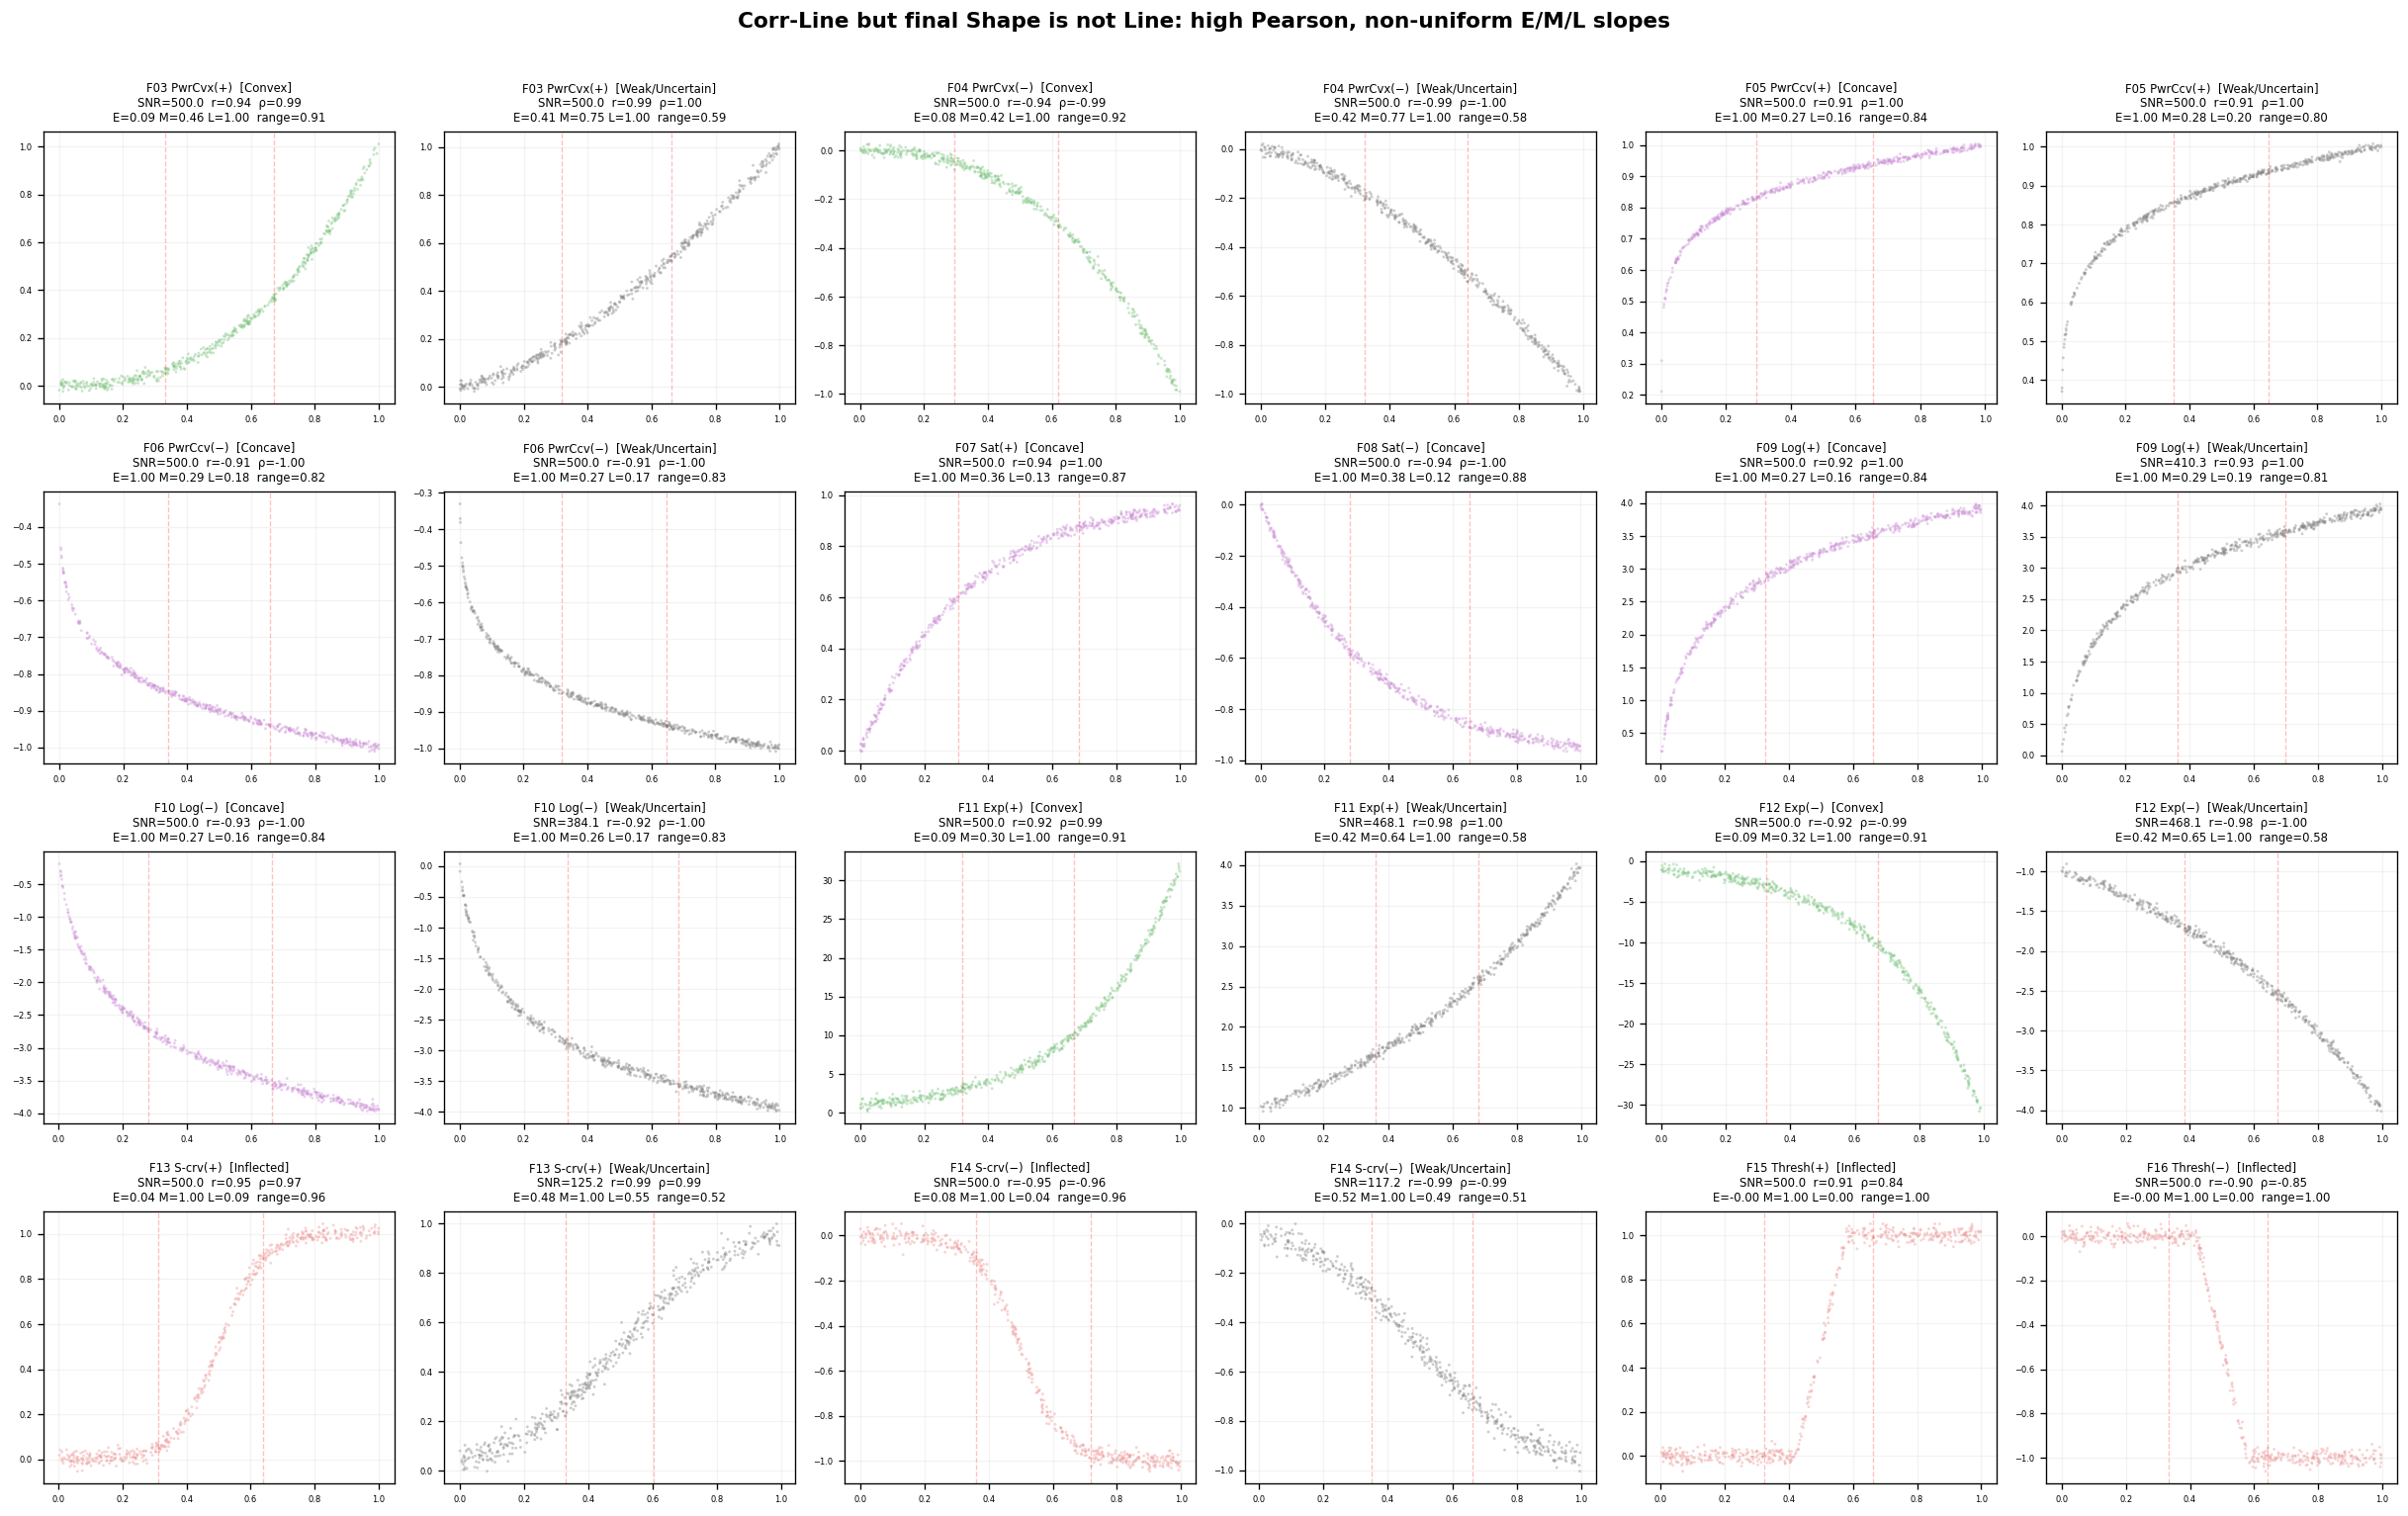

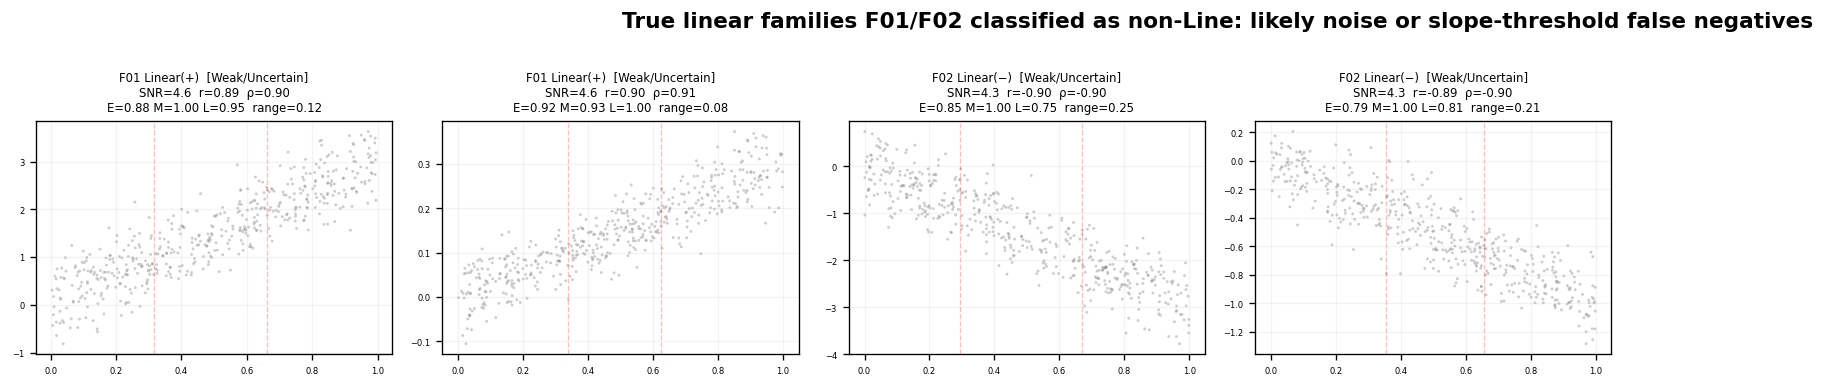

In [1032]:
# ── Diagnostic: visualize cases where "Line" correlation is not Shape=Line ──
# This separates two useful diagnostics:
#   1) Corr-Line but curved: |r| says Line, but E/M/L slopes say Convex/Concave/Inflected/U-shape.
#   2) True-line false negatives: F01/F02 cases whose final Shape is not Line.

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_to_idx = pd.Series(cases_df.index.values, index=cases_df['case_id']).to_dict()

# Recompute the slope uniformity score used by Shape=Line for display.
_abs_max = np.maximum.reduce([simple_cases['e_d'].abs(), simple_cases['m_d'].abs(), simple_cases['l_d'].abs()])
_abs_min = np.minimum.reduce([simple_cases['e_d'].abs(), simple_cases['m_d'].abs(), simple_cases['l_d'].abs()])
simple_cases['slope_uniformity_range'] = np.where(_abs_max > 0, (_abs_max - _abs_min) / _abs_max, np.nan)

corr_line_curved = simple_cases[
    (simple_cases['linearity'] == 'Line') &
    (simple_cases['shape'] != 'Line')
].copy()

true_line_false_neg = simple_cases[
    (simple_cases['family_id'].isin(['F01', 'F02'])) &
    (simple_cases['shape'] != 'Line')
].copy()

print('═══ Line Diagnostic ═══')
print(f'Corr-Line but Shape≠Line: {len(corr_line_curved):,} / {len(simple_cases):,} simple cases')
print(f'True-line F01/F02 but Shape≠Line: {len(true_line_false_neg):,}')
print()

if len(corr_line_curved):
    print('Corr-Line but Shape≠Line by family × shape:')
    display(pd.crosstab(corr_line_curved['family_id'], corr_line_curved['shape']))

if len(true_line_false_neg):
    print('True-line false negatives by family × shape:')
    display(pd.crosstab(true_line_false_neg['family_id'], true_line_false_neg['shape']))


def _pick_representatives(df, n_per_group=1, max_plots=36):
    if len(df) == 0:
        return df
    rows = []
    for _, g in df.groupby(['family_id', 'shape'], sort=True):
        finite = g[np.isfinite(g['snr_val'])].copy()
        if len(finite):
            # Show high-SNR cases first: if even high SNR is not Shape=Line, the pattern is structural.
            finite = finite.sort_values(['snr_val', 'slope_uniformity_range'], ascending=[False, False])
            rows.append(finite.head(n_per_group))
        else:
            rows.append(g.head(n_per_group))
    out = pd.concat(rows, ignore_index=False).sort_values(['family_id', 'shape'])
    return out.head(max_plots)


def _plot_case_grid(plot_df, title, ncols=6):
    if len(plot_df) == 0:
        print(f'No cases to plot for: {title}')
        return
    n = len(plot_df)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.15 * nrows))
    axes = np.array(axes).reshape(-1)

    shape_colors = {'Convex': '#81C784', 'Concave': '#CE93D8',
                    'Inflected': '#EF9A9A', 'U-shape': '#FFB74D',
                    'Other': '#BDBDBD'}

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        cid = int(row['case_id'])
        idx = case_to_idx.get(cid)
        if idx is None:
            ax.set_visible(False)
            continue
        x, y = X_all[idx], Y_all[idx]
        ax.scatter(x, y, s=3, alpha=0.42,
                   color=shape_colors.get(row['shape'], '#888'), edgecolors='none')

        x_sorted = np.sort(x)
        ax.axvline(x_sorted[len(x_sorted)//3], color='red', alpha=0.25, linewidth=0.8, linestyle='--')
        ax.axvline(x_sorted[2*len(x_sorted)//3], color='red', alpha=0.25, linewidth=0.8, linestyle='--')

        snr_txt = '∞' if np.isinf(row['snr_val']) else f'{row["snr_val"]:.1f}'
        ax.set_title(
            f'{row["family_id"]} {SHORT.get(row["family_id"], "")}  [{row["shape"]}]\n'
            f'SNR={snr_txt}  r={row["pearson_r"]:.2f}  ρ={row["spearman_rho"]:.2f}\n'
            f'E={row["e_d"]:.2f} M={row["m_d"]:.2f} L={row["l_d"]:.2f}  range={row["slope_uniformity_range"]:.2f}',
            fontsize=7,
        )
        ax.tick_params(labelsize=5)
        ax.grid(True, alpha=0.15)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


_plot_case_grid(
    _pick_representatives(corr_line_curved, n_per_group=1, max_plots=36),
    'Corr-Line but final Shape is not Line: high Pearson, non-uniform E/M/L slopes',
)

_plot_case_grid(
    _pick_representatives(true_line_false_neg, n_per_group=2, max_plots=18),
    'True linear families F01/F02 classified as non-Line: likely noise or slope-threshold false negatives',
)


In [1033]:
# ── Diagnostic: true Linear families classified as curved shapes ──
# Shows F01/F02 cases where final Shape is Convex / Concave / Inflected / U-shape.
# The titles show the direction-adjusted early/middle/late slopes used by the rule:
#   Convex:    E < M < L
#   Concave:   E > M > L
#   Inflected: M > E and M > L
#   U-shape:   M < E and M < L

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_to_idx = pd.Series(cases_df.index.values, index=cases_df['case_id']).to_dict()

# Recompute the slope uniformity score used by Shape=Line.
_abs_max = np.maximum.reduce([simple_cases['e_d'].abs(), simple_cases['m_d'].abs(), simple_cases['l_d'].abs()])
_abs_min = np.minimum.reduce([simple_cases['e_d'].abs(), simple_cases['m_d'].abs(), simple_cases['l_d'].abs()])
simple_cases['slope_uniformity_range'] = np.where(_abs_max > 0, (_abs_max - _abs_min) / _abs_max, np.nan)

linear_curved = simple_cases[
    (simple_cases['family_id'].isin(['F01', 'F02'])) &
    (simple_cases['shape'].isin(['Convex', 'Concave', 'Inflected', 'U-shape']))
].copy()

print('═══ True Linear Families Classified as Curved Shapes ═══')
print(f'F01/F02 curved-shape cases: {len(linear_curved):,}')
print(f'LINE_SLOPE_TOL = {LINE_SLOPE_TOL}; Shape=Line requires slope_uniformity_range < {LINE_SLOPE_TOL}')
print()

if len(linear_curved):
    summary = pd.crosstab(linear_curved['family_id'], linear_curved['shape'])
    display(summary)

    print('These cases usually fail Shape=Line because noise makes E/M/L slopes non-uniform,')
    print('then the E/M/L ordering rule assigns the largest matching curved-shape label.\n')

    shape_order = ['Convex', 'Concave', 'Inflected', 'U-shape']
    shape_colors = {'Convex': '#81C784', 'Concave': '#CE93D8',
                    'Inflected': '#EF9A9A', 'U-shape': '#FFB74D'}

    # Pick the most diagnostic examples: high SNR first, then biggest slope non-uniformity.
    plot_rows = []
    for fid in ['F01', 'F02']:
        for shp in shape_order:
            sub = linear_curved[(linear_curved['family_id'] == fid) & (linear_curved['shape'] == shp)].copy()
            if len(sub) == 0:
                continue
            finite = sub[np.isfinite(sub['snr_val'])].copy()
            if len(finite):
                finite = finite.sort_values(['snr_val', 'slope_uniformity_range'], ascending=[False, False])
                plot_rows.extend([row for _, row in finite.head(2).iterrows()])
            else:
                plot_rows.extend([row for _, row in sub.head(2).iterrows()])

    n = len(plot_rows)
    ncols = 4
    nrows = math.ceil(n / ncols) if n else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)

    def shape_reason(row):
        e, m, l = row['e_d'], row['m_d'], row['l_d']
        if row['shape'] == 'Convex':
            return 'E < M < L'
        if row['shape'] == 'Concave':
            return 'E > M > L'
        if row['shape'] == 'Inflected':
            return 'M is max'
        if row['shape'] == 'U-shape':
            return 'M is min'
        return ''

    for ax, row in zip(axes, plot_rows):
        cid = int(row['case_id'])
        idx = case_to_idx.get(cid)
        if idx is None:
            ax.set_visible(False)
            continue
        x, y = X_all[idx], Y_all[idx]
        shp = row['shape']
        ax.scatter(x, y, s=4, alpha=0.45, color=shape_colors.get(shp, '#888'), edgecolors='none')

        x_sorted = np.sort(x)
        ax.axvline(x_sorted[len(x_sorted)//3], color='red', alpha=0.28, linewidth=0.9, linestyle='--')
        ax.axvline(x_sorted[2*len(x_sorted)//3], color='red', alpha=0.28, linewidth=0.9, linestyle='--')

        snr_txt = '∞' if np.isinf(row['snr_val']) else f'{row["snr_val"]:.1f}'
        ax.set_title(
            f'{row["family_id"]} {SHORT.get(row["family_id"], "")} → {shp}\n'
            f'SNR={snr_txt}  r={row["pearson_r"]:.3f}  ρ={row["spearman_rho"]:.3f}\n'
            f'E={row["e_d"]:.2f}  M={row["m_d"]:.2f}  L={row["l_d"]:.2f}\n'
            f'{shape_reason(row)}; range={row["slope_uniformity_range"]:.2f} > {LINE_SLOPE_TOL}',
            fontsize=7,
        )
        ax.tick_params(labelsize=5)
        ax.grid(True, alpha=0.15)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle('F01/F02 true linear cases classified as curved: E/M/L slope diagnostics',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No F01/F02 cases were classified as curved shapes.')


═══ True Linear Families Classified as Curved Shapes ═══
F01/F02 curved-shape cases: 0
LINE_SLOPE_TOL = 0.15; Shape=Line requires slope_uniformity_range < 0.15

No F01/F02 cases were classified as curved shapes.


In [1034]:
# # ── LOWESS Diagnostic: why cases are classified as Inflected ──
# # Overlay scatter + global OLS line + LOWESS curve + early/middle/late segment fits.
# # This helps separate noisy true lines from genuinely S/threshold-like inflection patterns.

# try:
#     from statsmodels.nonparametric.smoothers_lowess import lowess
#     HAS_LOWESS = True
# except Exception as e:
#     HAS_LOWESS = False
#     print(f'LOWESS unavailable: {e}')

# from scipy.stats import linregress

# pts = np.load(S1_DIR / 'scatter_points.npz')
# X_all, Y_all = pts['x'], pts['y']
# cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
# case_to_idx = pd.Series(cases_df.index.values, index=cases_df['case_id']).to_dict()

# inflected_cases = simple_cases[simple_cases['shape'] == 'Inflected'].copy()
# true_linear_inflected = inflected_cases[inflected_cases['family_id'].isin(['F01', 'F02'])].copy()
# corr_line_inflected = inflected_cases[inflected_cases['linearity'] == 'Line'].copy()

# print('═══ LOWESS Diagnostic for Shape=Inflected ═══')
# print(f'All simple Shape=Inflected cases: {len(inflected_cases):,}')
# print(f'Corr-Line and Shape=Inflected:   {len(corr_line_inflected):,}')
# print(f'F01/F02 and Shape=Inflected:     {len(true_linear_inflected):,}')
# print()

# if len(inflected_cases):
#     print('Inflected counts by family:')
#     display(inflected_cases.groupby('family_id').size().rename('n_inflected').reset_index())


# def _pick_inflected_examples():
#     rows = []

#     # 1) Show true-linear false positives first, because these are the confusing ones.
#     for fid in ['F01', 'F02']:
#         sub = true_linear_inflected[true_linear_inflected['family_id'] == fid].copy()
#         if len(sub):
#             finite = sub[np.isfinite(sub['snr_val'])].copy()
#             if len(finite):
#                 finite = finite.sort_values(['snr_val', 'pearson_r'], ascending=[False, False])
#                 rows.extend([row for _, row in finite.head(3).iterrows()])
#             else:
#                 rows.extend([row for _, row in sub.head(3).iterrows()])

#     # 2) Then one high-SNR representative per other inflected family.
#     for fid in sorted(set(inflected_cases['family_id']) - {'F01', 'F02'}):
#         sub = inflected_cases[inflected_cases['family_id'] == fid].copy()
#         finite = sub[np.isfinite(sub['snr_val'])].copy()
#         if len(finite):
#             finite = finite.sort_values('snr_val', ascending=False)
#             rows.append(finite.iloc[0])
#         elif len(sub):
#             rows.append(sub.iloc[0])

#     return pd.DataFrame(rows).head(24)


# def _plot_lowess_inflected(plot_df, frac=0.25, ncols=4):
#     if len(plot_df) == 0:
#         print('No inflected cases to plot.')
#         return
#     n = len(plot_df)
#     nrows = math.ceil(n / ncols)
#     fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows))
#     axes = np.array(axes).reshape(-1)

#     for ax, (_, row) in zip(axes, plot_df.iterrows()):
#         cid = int(row['case_id'])
#         idx = case_to_idx.get(cid)
#         if idx is None:
#             ax.set_visible(False)
#             continue

#         x = np.asarray(X_all[idx], dtype=float)
#         y = np.asarray(Y_all[idx], dtype=float)
#         order = np.argsort(x)
#         xs, ys = x[order], y[order]
#         n_pts = len(xs)
#         cut1, cut2 = n_pts // 3, 2 * n_pts // 3

#         ax.scatter(xs, ys, s=4, alpha=0.35, color='#EF9A9A', edgecolors='none', label='points')

#         # Global OLS fit.
#         if n_pts >= 3:
#             g = linregress(xs, ys)
#             ax.plot(xs, g.intercept + g.slope * xs, color='black', linewidth=1.2, alpha=0.85, label='global line')

#         # LOWESS fit.
#         lowess_changes = np.nan
#         if HAS_LOWESS:
#             fit = lowess(ys, xs, frac=frac, return_sorted=True)
#             ax.plot(fit[:, 0], fit[:, 1], color='#D32F2F', linewidth=1.8, alpha=0.95, label=f'LOWESS {frac}')
#             dx = np.diff(fit[:, 0])
#             dy = np.diff(fit[:, 1])
#             ok = dx != 0
#             slopes = dy[ok] / dx[ok]
#             signs = np.sign(slopes)
#             signs = signs[signs != 0]
#             lowess_changes = int(np.sum(signs[1:] != signs[:-1])) if len(signs) >= 2 else 0

#         # Segment OLS fits.
#         for lo, hi, color, label in [
#             (0, cut1, '#1976D2', 'early'),
#             (cut1, cut2, '#388E3C', 'middle'),
#             (cut2, n_pts, '#F57C00', 'late'),
#         ]:
#             if hi - lo >= 3:
#                 s = linregress(xs[lo:hi], ys[lo:hi])
#                 ax.plot(xs[lo:hi], s.intercept + s.slope * xs[lo:hi],
#                         color=color, linewidth=1.4, alpha=0.9, label=label)

#         ax.axvline(xs[cut1], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')
#         ax.axvline(xs[cut2], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')

#         snr_txt = '∞' if np.isinf(row['snr_val']) else f'{row["snr_val"]:.1f}'
#         ax.set_title(
#             f'{row["family_id"]} {SHORT.get(row["family_id"], "")} → Inflected\n'
#             f'SNR={snr_txt}  r={row["pearson_r"]:.3f}  ρ={row["spearman_rho"]:.3f}\n'
#             f'E={row["e_d"]:.2f}  M={row["m_d"]:.2f}  L={row["l_d"]:.2f}  LOWESS tp={lowess_changes}',
#             fontsize=7,
#         )
#         ax.tick_params(labelsize=5)
#         ax.grid(True, alpha=0.15)

#     for ax in axes[n:]:
#         ax.set_visible(False)

#     handles, labels = axes[0].get_legend_handles_labels()
#     fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 1.01))
#     fig.suptitle('Shape=Inflected diagnostic: scatter + global line + LOWESS + segment fits',
#                  fontsize=13, fontweight='bold', y=1.05)
#     plt.tight_layout()
#     plt.show()


# _plot_lowess_inflected(_pick_inflected_examples(), frac=0.25, ncols=4)


═══ F03-F06 Power Families Classified as Shape=Line ═══
Power-family Shape=Line cases: 1,064


,family_id,n_line
0,F03,21
1,F04,10
2,F05,515
3,F06,518


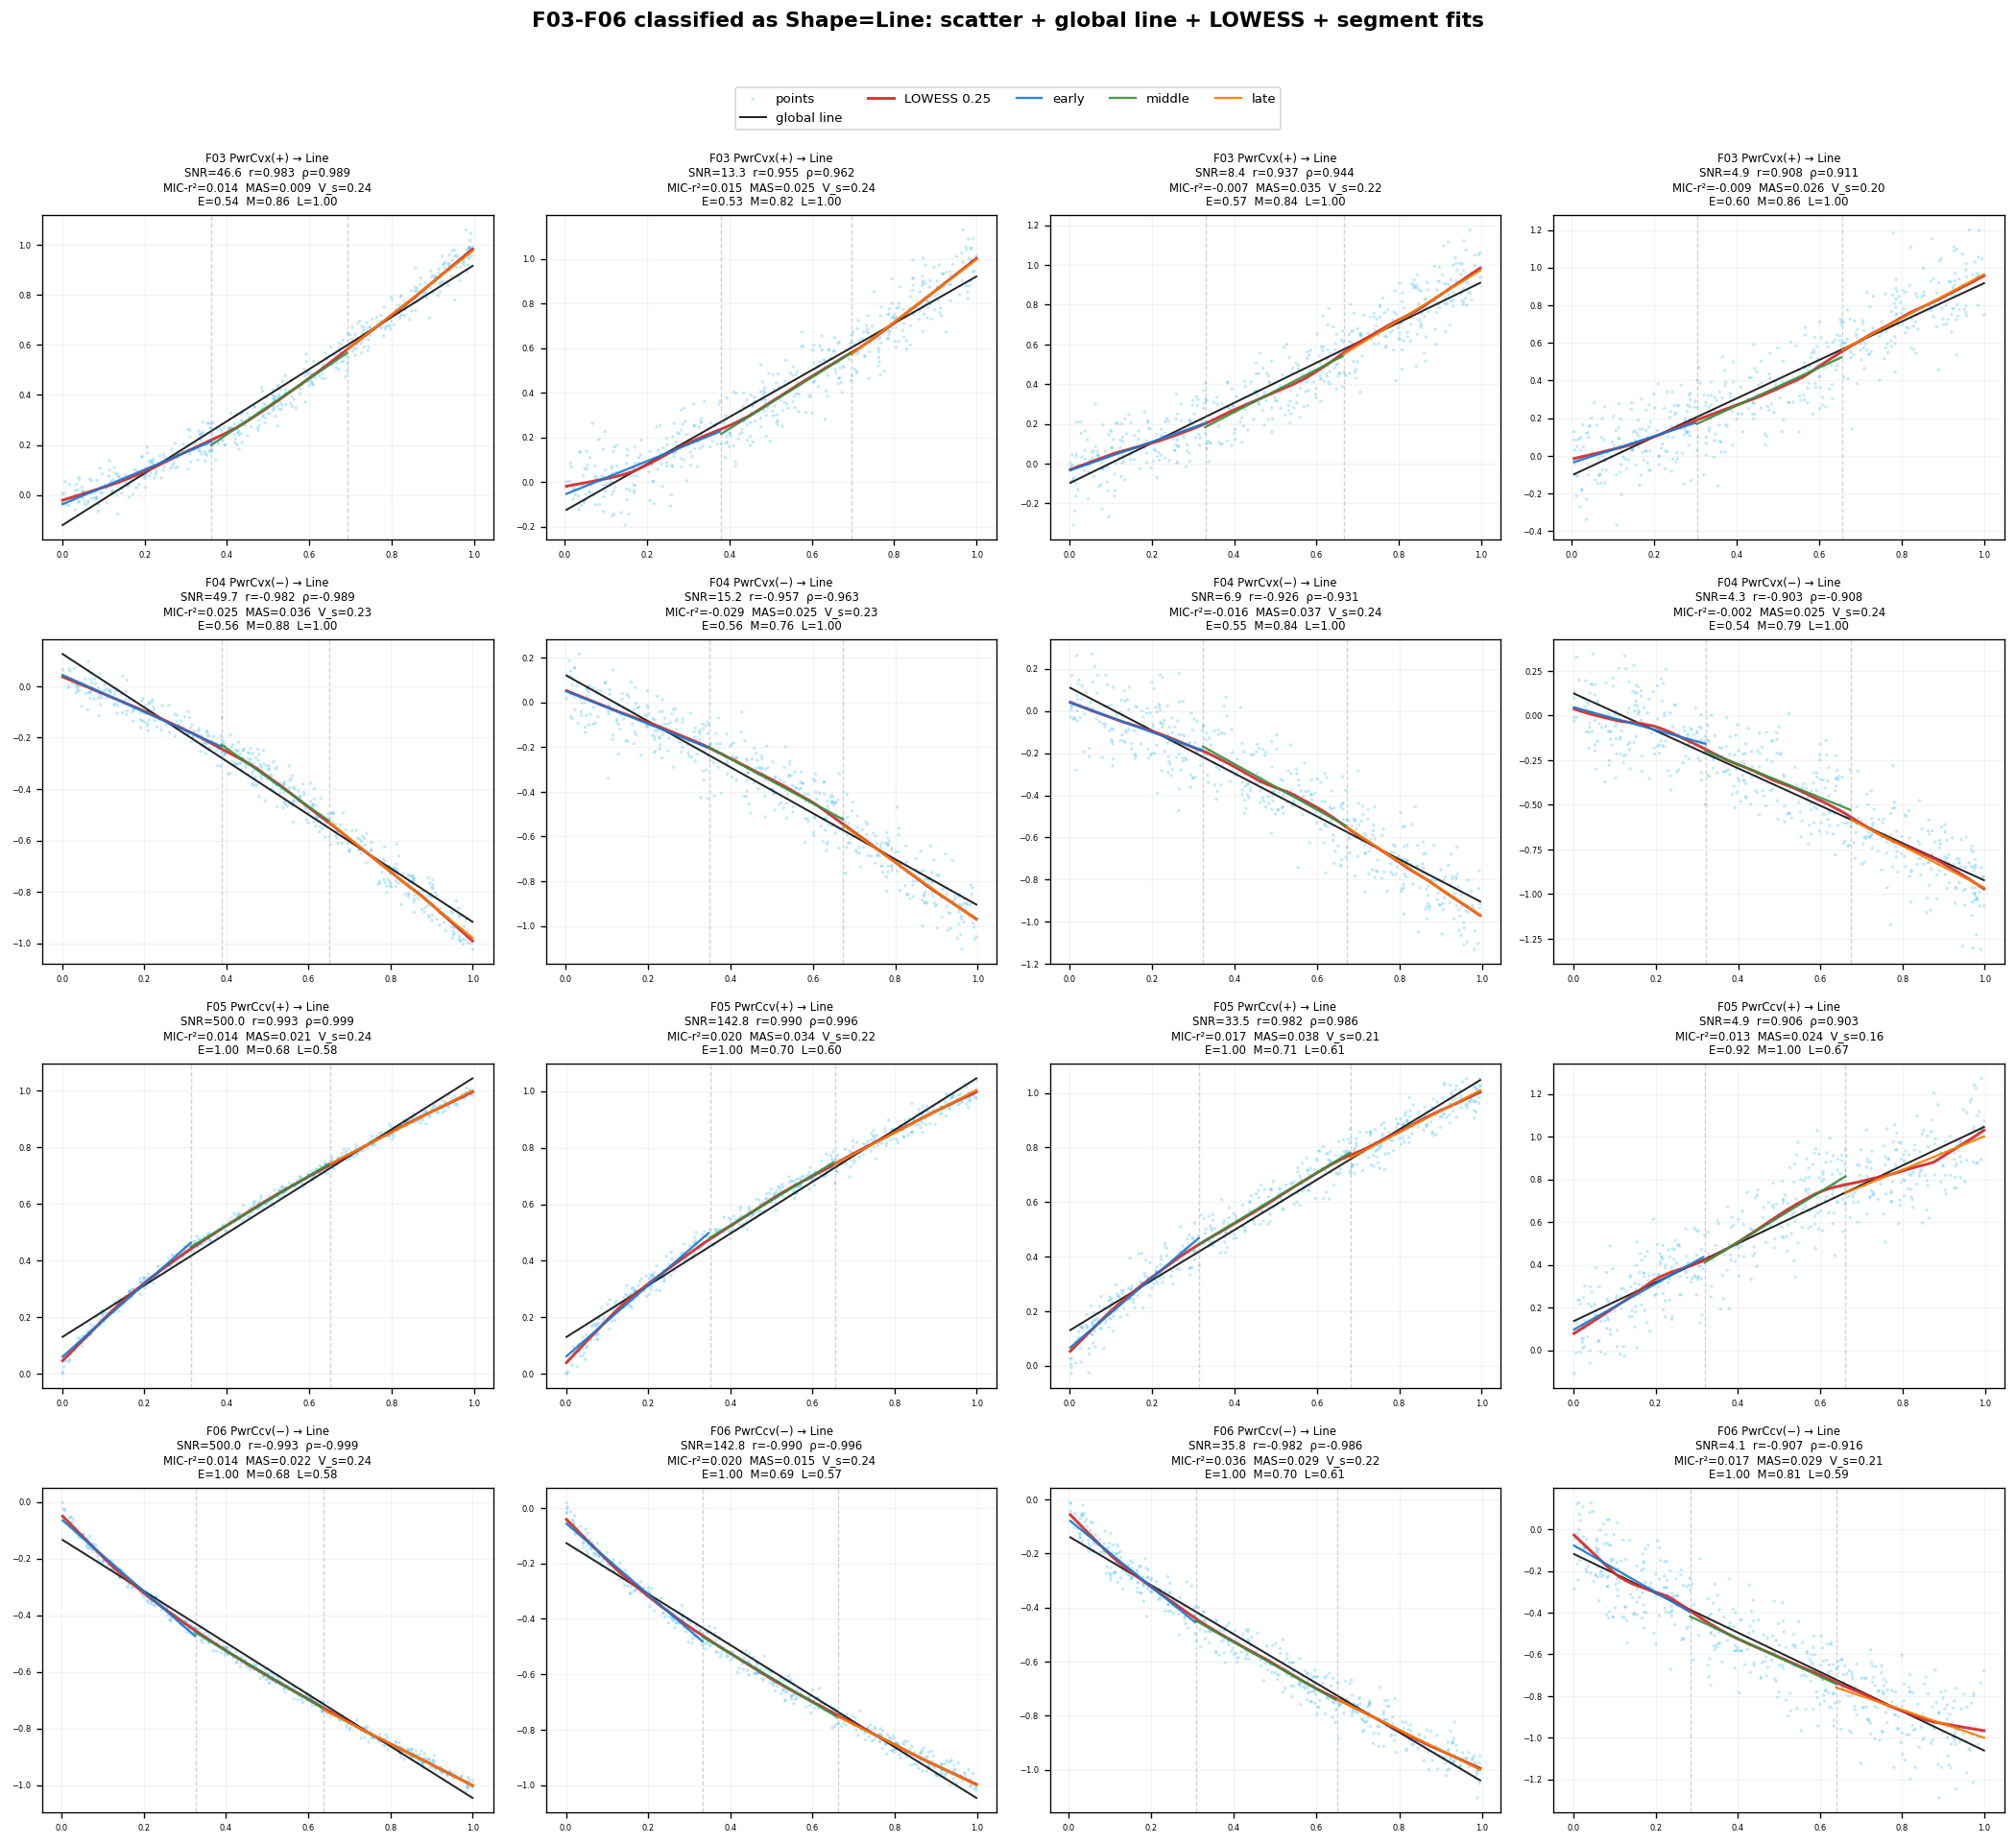

In [1035]:
# ── Diagnostic: F03-F06 power families classified as Line ──
# These are nonlinear power families, so Shape=Line means the observed case is close enough
# to linear under the current single-plot rules. Overlay scatter + global OLS + LOWESS + E/M/L fits.

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except Exception as e:
    HAS_LOWESS = False
    print(f'LOWESS unavailable: {e}')

from scipy.stats import linregress

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_to_idx = pd.Series(cases_df.index.values, index=cases_df['case_id']).to_dict()

power_line = simple_cases[
    simple_cases['family_id'].isin(['F03', 'F04', 'F05', 'F06']) &
    (simple_cases['shape'] == 'Line')
].copy()

print('═══ F03-F06 Power Families Classified as Shape=Line ═══')
print(f'Power-family Shape=Line cases: {len(power_line):,}')
if len(power_line):
    cols = ['family_id', 'variant_name'] if 'variant_name' in power_line.columns else ['family_id']
    display(power_line.groupby(cols).size().rename('n_line').reset_index())


def _pick_power_line_examples(max_per_family=4):
    rows = []
    for fid in ['F03', 'F04', 'F05', 'F06']:
        sub = power_line[power_line['family_id'] == fid].copy()
        if len(sub) == 0:
            continue
        finite = sub[np.isfinite(sub['snr_val'])].copy()
        if len(finite):
            # Show a spread: highest SNR first, then a few lower SNR examples.
            finite = finite.sort_values('snr_val', ascending=False)
            picks = []
            picks.append(finite.iloc[0])
            if len(finite) > 2:
                picks.append(finite.iloc[len(finite)//3])
            if len(finite) > 4:
                picks.append(finite.iloc[2*len(finite)//3])
            if len(finite) > 1:
                picks.append(finite.iloc[-1])
            rows.extend(picks[:max_per_family])
        else:
            rows.extend([row for _, row in sub.head(max_per_family).iterrows()])
    return pd.DataFrame(rows).head(20)


def _plot_power_line_cases(plot_df, frac=0.25, ncols=4):
    if len(plot_df) == 0:
        print('No F03-F06 Shape=Line cases to plot.')
        return
    n = len(plot_df)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        cid = int(row['case_id'])
        idx = case_to_idx.get(cid)
        if idx is None:
            ax.set_visible(False)
            continue

        x = np.asarray(X_all[idx], dtype=float)
        y = np.asarray(Y_all[idx], dtype=float)
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        n_pts = len(xs)
        cut1, cut2 = n_pts // 3, 2 * n_pts // 3

        ax.scatter(xs, ys, s=4, alpha=0.35, color='#4FC3F7', edgecolors='none', label='points')

        # Global OLS fit.
        if n_pts >= 3:
            g = linregress(xs, ys)
            ax.plot(xs, g.intercept + g.slope * xs, color='black', linewidth=1.2, alpha=0.85, label='global line')

        # LOWESS fit.
        if HAS_LOWESS:
            fit = lowess(ys, xs, frac=frac, return_sorted=True)
            ax.plot(fit[:, 0], fit[:, 1], color='#D32F2F', linewidth=1.8, alpha=0.95, label=f'LOWESS {frac}')

        # Segment OLS fits.
        for lo, hi, color, label in [
            (0, cut1, '#1976D2', 'early'),
            (cut1, cut2, '#388E3C', 'middle'),
            (cut2, n_pts, '#F57C00', 'late'),
        ]:
            if hi - lo >= 3:
                s = linregress(xs[lo:hi], ys[lo:hi])
                ax.plot(xs[lo:hi], s.intercept + s.slope * xs[lo:hi],
                        color=color, linewidth=1.4, alpha=0.9, label=label)

        ax.axvline(xs[cut1], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')
        ax.axvline(xs[cut2], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')

        snr_txt = '∞' if np.isinf(row['snr_val']) else f'{row["snr_val"]:.1f}'
        vs_txt = f'{row["slope_Vs"]:.2f}' if 'slope_Vs' in row and np.isfinite(row['slope_Vs']) else 'NA'
        mr_txt = f'{row["MIC_minus_r2"]:.3f}' if 'MIC_minus_r2' in row else 'NA'
        ax.set_title(
            f'{row["family_id"]} {SHORT.get(row["family_id"], "")} → Line\n'
            f'SNR={snr_txt}  r={row["pearson_r"]:.3f}  ρ={row["spearman_rho"]:.3f}\n'
            f'MIC-r²={mr_txt}  MAS={row["MAS"]:.3f}  V_s={vs_txt}\n'
            f'E={row["e_d"]:.2f}  M={row["m_d"]:.2f}  L={row["l_d"]:.2f}',
            fontsize=7,
        )
        ax.tick_params(labelsize=5)
        ax.grid(True, alpha=0.15)

    for ax in axes[n:]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle('F03-F06 classified as Shape=Line: scatter + global line + LOWESS + segment fits',
                 fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()


_plot_power_line_cases(_pick_power_line_examples(max_per_family=4), frac=0.25, ncols=4)


In [1036]:
# ── Diagnostic: F21 cases classified as U-shape ──
# Plot the F21 cases that passed the Simple path but were classified as U-shape.
# Overlay scatter + global OLS + LOWESS + early/middle/late segment fits.

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    HAS_LOWESS = True
except Exception as e:
    HAS_LOWESS = False
    print(f'LOWESS unavailable: {e}')

from scipy.stats import linregress

pts = np.load(S1_DIR / 'scatter_points.npz')
X_all, Y_all = pts['x'], pts['y']
cases_df = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
case_to_idx = pd.Series(cases_df.index.values, index=cases_df['case_id']).to_dict()

f21_ushape = simple_cases[
    (simple_cases['family_id'] == 'F21') &
    (simple_cases['shape'] == 'U-shape')
].copy()

print('═══ F21 Classified as U-shape ═══')
print(f'F21 U-shape cases: {len(f21_ushape):,}')
if len(f21_ushape):
    cols = ['case_id', 'snr_val', 'pearson_r', 'spearman_rho', 'MIC_minus_r2', 'MAS', 'e_d', 'm_d', 'l_d']
    if 'slope_Vs' in f21_ushape.columns:
        cols.append('slope_Vs')
    display(f21_ushape[cols].sort_values('snr_val', ascending=False))


def _plot_f21_ushape(plot_df, frac=0.25, ncols=2):
    if len(plot_df) == 0:
        print('No F21 U-shape cases to plot.')
        return
    n = len(plot_df)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        cid = int(row['case_id'])
        idx = case_to_idx.get(cid)
        if idx is None:
            ax.set_visible(False)
            continue

        x = np.asarray(X_all[idx], dtype=float)
        y = np.asarray(Y_all[idx], dtype=float)
        order = np.argsort(x)
        xs, ys = x[order], y[order]
        n_pts = len(xs)
        cut1, cut2 = n_pts // 3, 2 * n_pts // 3

        ax.scatter(xs, ys, s=6, alpha=0.4, color='#FFB74D', edgecolors='none', label='points')

        if n_pts >= 3:
            g = linregress(xs, ys)
            ax.plot(xs, g.intercept + g.slope * xs, color='black', linewidth=1.2, alpha=0.85, label='global line')

        lowess_changes = np.nan
        if HAS_LOWESS:
            fit = lowess(ys, xs, frac=frac, return_sorted=True)
            ax.plot(fit[:, 0], fit[:, 1], color='#D32F2F', linewidth=1.8, alpha=0.95, label=f'LOWESS {frac}')
            dx = np.diff(fit[:, 0])
            dy = np.diff(fit[:, 1])
            ok = dx != 0
            slopes = dy[ok] / dx[ok]
            signs = np.sign(slopes)
            signs = signs[signs != 0]
            lowess_changes = int(np.sum(signs[1:] != signs[:-1])) if len(signs) >= 2 else 0

        for lo, hi, color, label in [
            (0, cut1, '#1976D2', 'early'),
            (cut1, cut2, '#388E3C', 'middle'),
            (cut2, n_pts, '#F57C00', 'late'),
        ]:
            if hi - lo >= 3:
                s = linregress(xs[lo:hi], ys[lo:hi])
                ax.plot(xs[lo:hi], s.intercept + s.slope * xs[lo:hi],
                        color=color, linewidth=1.5, alpha=0.9, label=label)

        ax.axvline(xs[cut1], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')
        ax.axvline(xs[cut2], color='gray', alpha=0.35, linewidth=0.8, linestyle='--')

        snr_txt = '∞' if np.isinf(row['snr_val']) else f'{row["snr_val"]:.1f}'
        vs_txt = f'{row["slope_Vs"]:.2f}' if 'slope_Vs' in row and np.isfinite(row['slope_Vs']) else 'NA'
        ax.set_title(
            f'F21 Cubic → U-shape\n'
            f'case={cid}  SNR={snr_txt}  r={row["pearson_r"]:.3f}  ρ={row["spearman_rho"]:.3f}\n'
            f'MIC-r²={row["MIC_minus_r2"]:.3f}  MAS={row["MAS"]:.3f}  V_s={vs_txt}\n'
            f'E={row["e_d"]:.2f}  M={row["m_d"]:.2f}  L={row["l_d"]:.2f}  LOWESS tp={lowess_changes}',
            fontsize=8,
        )
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.15)

    for ax in axes[n:]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle('F21 cases classified as U-shape: scatter + global line + LOWESS + segment fits',
                 fontsize=13, fontweight='bold', y=1.08)
    plt.tight_layout()
    plt.show()


_plot_f21_ushape(f21_ushape.sort_values('snr_val', ascending=False), frac=0.25, ncols=2)


═══ F21 Classified as U-shape ═══
F21 U-shape cases: 0
No F21 U-shape cases to plot.


In [1037]:
# ── Export: full classification path for all 26 families ──

filtered_cases.to_csv(S2_DIR / 'filtered_MIC_dcor.csv', index=False)
print(f'Saved {len(filtered_cases):,} qualifying cases → filtered_MIC_dcor.csv')

# ── Build per-family classification summary ──
total_per_fid = signal.groupby('family_id').size()

export_rows = []
for fid in all_fids:
    row = {'family_id': fid, 'short_name': SHORT.get(fid, '')}
    n_total = int(total_per_fid.get(fid, 0))

    # L1
    l1_pass = len(filtered_cases[filtered_cases['family_id'] == fid])
    row.update({'L1_pass': l1_pass, 'L1_total': n_total,
                'L1_pct': l1_pass / n_total if n_total else 0,
                'L1_result': 'Pass' if l1_pass > 0 else 'Fail'})

    dash_cols = ['L2_simple','L2_complex','L2_total','L2_result',
                 'dir_pos','dir_neg','dir_total','dir_result',
                 'mono_strong','mono_med','mono_total','mono_result',
                 'lin_line','lin_med','lin_total','lin_result',
                 'shape_line','shape_convex','shape_concave','shape_inflected',
                 'shape_ushape','shape_weak_uncertain','shape_other','shape_total','shape_result',
                 'profile']

    if l1_pass == 0:
        row.update({c: '—' for c in dash_cols})
        export_rows.append(row)
        continue

    # L2
    fid_sc = sc[sc['family_id'] == fid]
    n_s = int(fid_sc['is_simple'].sum())
    n_c = int((~fid_sc['is_simple']).sum())
    row.update({'L2_simple': n_s, 'L2_complex': n_c, 'L2_total': l1_pass,
                'L2_result': 'Simple' if n_s > n_c else ('Complex' if n_c > n_s else 'Mixed')})

    simple_cols = [c for c in dash_cols if c not in ['L2_simple','L2_complex','L2_total','L2_result']]
    if n_s == 0:
        row.update({c: '—' for c in simple_cols})
        export_rows.append(row)
        continue

    fid_simple = simple_cases[simple_cases['family_id'] == fid]

    # Direction
    n_pos = int((fid_simple['direction'] == 'Positive').sum())
    n_neg = int((fid_simple['direction'] == 'Negative').sum())
    row.update({'dir_pos': n_pos, 'dir_neg': n_neg, 'dir_total': n_s,
                'dir_result': fid_simple['direction'].mode().iloc[0]})

    # Monotonicity
    n_ms = int((fid_simple['monotonicity'] == 'Strong').sum())
    n_mm = int((fid_simple['monotonicity'] == 'Med').sum())
    row.update({'mono_strong': n_ms, 'mono_med': n_mm, 'mono_total': n_s,
                'mono_result': fid_simple['monotonicity'].mode().iloc[0]})

    # Linearity
    n_ll = int((fid_simple['linearity'] == 'Line').sum())
    n_lm = int((fid_simple['linearity'] == 'Med').sum())
    row.update({'lin_line': n_ll, 'lin_med': n_lm, 'lin_total': n_s,
                'lin_result': fid_simple['linearity'].mode().iloc[0]})

    # Shape (unified: Line / Convex / Concave / Inflected / U-shape / Other)
    shape_key_map = {
        'Line': 'shape_line',
        'Convex': 'shape_convex',
        'Concave': 'shape_concave',
        'Inflected': 'shape_inflected',
        'U-shape': 'shape_ushape',
        'Weak/Uncertain': 'shape_weak_uncertain',
        'Other': 'shape_other',
    }
    for s_name, key in shape_key_map.items():
        row[key] = int((fid_simple['shape'] == s_name).sum())
    row['shape_total'] = n_s
    row['shape_result'] = fid_simple['shape'].mode().iloc[0]

    # Profile
    d = '+' if row['dir_result'] == 'Positive' else '−'
    row['profile'] = f"{d}, {row['mono_result']}, {row['shape_result']}"

    export_rows.append(row)

cls_df = pd.DataFrame(export_rows)
cls_path = S2_DIR / 'simple_path_classification.csv'
cls_df.to_csv(cls_path, index=False)
print(f'Saved classification → {cls_path.name}')

# ── Print summary ──
print(f'\n═══ Classification Summary (all {len(all_fids)} families) ═══\n')

hdr = f'{"Family":<16} {"L1":>5} {"L2":>7} {"Dir":>4} {"Mono":>6} {"Lin":>5} {"Shape":>10} {"Profile"}'
print(hdr)
print('─' * len(hdr))
for _, r in cls_df.iterrows():
    fid = r['family_id']
    l1 = r['L1_result'][:4]
    l2 = str(r['L2_result'])[:7] if r['L2_result'] != '—' else '—'
    dr = ('+' if r['dir_result'] == 'Positive' else '−') if r['dir_result'] != '—' else '—'
    mo = str(r['mono_result'])[:6] if r['mono_result'] != '—' else '—'
    li = str(r['lin_result'])[:5] if r['lin_result'] != '—' else '—'
    sh = str(r['shape_result'])[:10] if r['shape_result'] != '—' else '—'
    pr = str(r['profile']) if r['profile'] != '—' else '—'
    print(f'{fid} {SHORT[fid]:<10} {l1:>5} {l2:>7} {dr:>4} {mo:>6} {li:>5} {sh:>10}  {pr}')


# ── Export classification as readable txt ──
txt_path = S2_DIR / 'simple_path_classification.txt'
with open(txt_path, 'w') as f:
    f.write('═══ Scheme C: Simple Path Classification ═══\n')
    f.write(f'MIC ≥ {MIC_THRESH}, dCor ≥ {DCOR_THRESH}, MIC-r² < {MR_THRESH}, |r| ≥ {R_THRESH}, |ρ| ≥ {R_THRESH}\n')
    f.write('Shape classification: Line rule first, then E/M/L ordering for curved shapes\n')
    if 'LINE_VS_TOL' in globals():
        f.write(f'  LINE_VS_TOL = {LINE_VS_TOL} (if USE_SLOPE_CHECK=True, V_s < tol → Line)\n')
    if 'LINE_SLOPE_TOL' in globals():
        f.write(f'  LINE_SLOPE_TOL = {LINE_SLOPE_TOL} (legacy range/max threshold)\n')
    f.write(f'  USE_SLOPE_CHECK = {USE_SLOPE_CHECK}\n\n')

    # L2
    f.write('── L2: Simple or Complex? ──\n')
    hdr_txt = f'{"Family":<16} {"Simple":>7} {"Complex":>8} {"Total":>7} {"Simple%":>8}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for fid in qual_fids:
        n_s = len(simple_cases[simple_cases['family_id'] == fid])
        n_c = len(sc[sc['family_id'] == fid]) - n_s
        n_t = n_s + n_c
        pct = n_s / n_t if n_t > 0 else 0
        f.write(f'{fid} {SHORT[fid]:<10} {n_s:>7,} {n_c:>8,} {n_t:>7,} {pct:>7.0%}\n')

    # Direction
    f.write(f'\n── Direction (sign of Pearson r) ──\n')
    hdr_txt = f'{"Family":<16} {"Pos(+)":>7} {"Neg(−)":>7} {"Total":>7} {"Majority":>9}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for fid in simple_fids:
        sub = simple_cases[simple_cases['family_id'] == fid]
        n_pos = int((sub['direction'] == 'Positive').sum())
        n_neg = int((sub['direction'] == 'Negative').sum())
        maj = '+' if n_pos >= n_neg else '−'
        f.write(f'{fid} {SHORT[fid]:<10} {n_pos:>7,} {n_neg:>7,} {len(sub):>7,} {maj:>9}\n')

    # Monotonicity
    f.write(f'\n── Monotonicity (|ρ| ≥ {MONO_STRONG} → Strong) ──\n')
    hdr_txt = f'{"Family":<16} {"Strong":>7} {"Med":>7} {"Total":>7} {"Majority":>9}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for fid in simple_fids:
        sub = simple_cases[simple_cases['family_id'] == fid]
        n_s = int((sub['monotonicity'] == 'Strong').sum())
        n_m = int((sub['monotonicity'] == 'Med').sum())
        maj = 'Strong' if n_s >= n_m else 'Med'
        f.write(f'{fid} {SHORT[fid]:<10} {n_s:>7,} {n_m:>7,} {len(sub):>7,} {maj:>9}\n')

    # Linearity
    f.write(f'\n── Linearity (|r| ≥ {LIN_STRONG} → Line) ──\n')
    hdr_txt = f'{"Family":<16} {"Line":>7} {"Med":>7} {"Total":>7} {"Majority":>9}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for fid in simple_fids:
        sub = simple_cases[simple_cases['family_id'] == fid]
        n_l = int((sub['linearity'] == 'Line').sum())
        n_m = int((sub['linearity'] == 'Med').sum())
        maj = 'Line' if n_l >= n_m else 'Med'
        f.write(f'{fid} {SHORT[fid]:<10} {n_l:>7,} {n_m:>7,} {len(sub):>7,} {maj:>9}\n')

    # Shape classification (unified)
    f.write(f'\n── Shape (unified: Line + Curvature) ──\n')
    hdr_txt = f'{"Family":<16} {"Line":>6} {"Convex":>7} {"Concave":>8} {"Inflect":>8} {"U-shp":>6} {"Weak":>6} {"Total":>7} {"Majority":>9}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for fid in simple_fids:
        sub = simple_cases[simple_cases['family_id'] == fid]
        n = len(sub)
        shape_names = ['Line','Convex','Concave','Inflected','U-shape','Weak/Uncertain','Other']
        counts = {s: int((sub['shape'] == s).sum()) for s in shape_names}
        maj = sub['shape'].mode().iloc[0]
        f.write(f'{fid} {SHORT[fid]:<10} {counts["Line"]:>6,} {counts["Convex"]:>7,} {counts["Concave"]:>8,} {counts["Inflected"]:>8,} {counts["U-shape"]:>6,} {counts["Weak/Uncertain"]:>6,} {n:>7,} {maj:>9}\n')

    # Summary
    f.write(f'\n── Summary ──\n')
    hdr_txt = f'{"Family":<16} {"L1":>5} {"L2":>7} {"Dir":>4} {"Mono":>6} {"Lin":>5} {"Shape":>10} {"Profile"}\n'
    f.write(hdr_txt)
    f.write('─' * len(hdr_txt.rstrip()) + '\n')
    for _, r in cls_df.iterrows():
        fid = r['family_id']
        l1 = str(r['L1_result'])[:4]
        l2 = str(r['L2_result'])[:7] if r['L2_result'] != '—' else '—'
        dr = ('+' if r['dir_result'] == 'Positive' else '−') if r['dir_result'] != '—' else '—'
        mo = str(r['mono_result'])[:6] if r['mono_result'] != '—' else '—'
        li = str(r['lin_result'])[:5] if r['lin_result'] != '—' else '—'
        sh = str(r['shape_result'])[:10] if r['shape_result'] != '—' else '—'
        pr = str(r['profile']) if r['profile'] != '—' else '—'
        f.write(f'{fid} {SHORT[fid]:<10} {l1:>5} {l2:>7} {dr:>4} {mo:>6} {li:>5} {sh:>10}  {pr}\n')

print(f'Saved readable classification → {txt_path.name}')


Saved 32,570 qualifying cases → filtered_MIC_dcor.csv
Saved classification → simple_path_classification.csv

═══ Classification Summary (all 26 families) ═══

Family              L1      L2  Dir   Mono   Lin      Shape Profile
───────────────────────────────────────────────────────────────────
F01 Linear(+)   Pass  Simple    + Strong  Line       Line  +, Strong, Line
F02 Linear(−)   Pass  Simple    − Strong  Line       Line  −, Strong, Line
F03 PwrCvx(+)   Pass  Simple    + Strong  Line     Convex  +, Strong, Convex
F04 PwrCvx(−)   Pass  Simple    − Strong  Line     Convex  −, Strong, Convex
F05 PwrCcv(+)   Pass  Simple    + Strong  Line    Concave  +, Strong, Concave
F06 PwrCcv(−)   Pass  Simple    − Strong  Line    Concave  −, Strong, Concave
F07 Sat(+)      Pass  Simple    + Strong  Line    Concave  +, Strong, Concave
F08 Sat(−)      Pass  Simple    − Strong  Line    Concave  −, Strong, Concave
F09 Log(+)      Pass  Simple    + Strong  Line    Concave  +, Strong, Concave
F10 Log(−) 